In [1]:
# Cell 1: Imports and Configuration

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from scipy import stats
from scipy.stats import zscore

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     RandomizedSearchCV, cross_val_score,
                                     StratifiedKFold)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import RFE, VarianceThreshold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: "%.3f" % x)

plt.rcParams["figure.dpi"]      = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("All libraries imported successfully.")
print(f"TensorFlow version : {tf.__version__}")
print(f"Scikit-learn version: ", end="")
import sklearn; print(sklearn.__version__)

All libraries imported successfully.
TensorFlow version : 2.20.0
Scikit-learn version: 1.6.1


In [2]:
# Cell 2: Load Dataset

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

column_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

df_raw = pd.read_csv(url, names=column_names, na_values="?")

print("Dataset loaded successfully.")
print(f"Shape: {df_raw.shape}")
print("\nFirst 5 rows:")
df_raw.head()

Dataset loaded successfully.
Shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.000,1.000,1.000,145.000,233.000,1.000,2.000,150.000,0.000,2.300,3.000,0.000,6.000,0
1,67.000,1.000,4.000,160.000,286.000,0.000,2.000,108.000,1.000,1.500,2.000,3.000,3.000,2
2,67.000,1.000,4.000,120.000,229.000,0.000,2.000,129.000,1.000,2.600,2.000,2.000,7.000,1
3,37.000,1.000,3.000,130.000,250.000,0.000,0.000,187.000,0.000,3.500,3.000,0.000,3.000,0
4,41.000,0.000,2.000,130.000,204.000,0.000,2.000,172.000,0.000,1.400,1.000,0.000,3.000,0


In [3]:
# Cell 3: Data Inspection

print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)

print(f"\nShape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")

print("\nData Types:")
print(df_raw.dtypes)

print("\nBasic Statistics:")
df_raw.describe()

DATASET STRUCTURE

Shape: 303 rows x 14 columns

Data Types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Basic Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000,303.000,303.000,303.000,303.000,303.000,303.000,303.000,303.000,303.000,303.000,299.000,301.000,303.000
mean,54.439,0.680,3.158,131.690,246.693,0.149,0.990,149.607,0.327,1.040,1.601,0.672,4.734,0.937
std,9.039,0.467,0.960,17.600,51.777,0.356,0.995,22.875,0.470,1.161,0.616,0.937,1.940,1.229
min,29.000,0.000,1.000,94.000,126.000,0.000,0.000,71.000,0.000,0.000,1.000,0.000,3.000,0.000
25%,48.000,0.000,3.000,120.000,211.000,0.000,0.000,133.500,0.000,0.000,1.000,0.000,3.000,0.000
50%,56.000,1.000,3.000,130.000,241.000,0.000,1.000,153.000,0.000,0.800,2.000,0.000,3.000,0.000
75%,61.000,1.000,4.000,140.000,275.000,0.000,2.000,166.000,1.000,1.600,2.000,1.000,7.000,2.000
max,77.000,1.000,4.000,200.000,564.000,1.000,2.000,202.000,1.000,6.200,3.000,3.000,7.000,4.000


In [4]:
# Cell 4: Missing Values and Duplicates Analysis

def missing_value_report(df):
    """Returns a dataframe summarising missing values per column."""
    total     = df.isnull().sum()
    percent   = (total / len(df)) * 100
    dtypes    = df.dtypes
    report    = pd.DataFrame({
        "Missing Count"  : total,
        "Missing Percent": percent,
        "Data Type"      : dtypes
    })
    report = report[report["Missing Count"] > 0].sort_values("Missing Percent", ascending=False)
    return report


def duplicate_report(df):
    """Prints duplicate row count and percentage."""
    dup_count = df.duplicated().sum()
    dup_pct   = (dup_count / len(df)) * 100
    print(f"Duplicate rows : {dup_count}  ({dup_pct:.2f}%)")


def target_distribution(df, target_col):
    """Prints target class distribution."""
    counts = df[target_col].value_counts()
    pct    = df[target_col].value_counts(normalize=True) * 100
    dist   = pd.DataFrame({"Count": counts, "Percent": pct})
    print("\nTarget Distribution:")
    print(dist)


print("=" * 60)
print("MISSING VALUE REPORT")
print("=" * 60)
mv = missing_value_report(df_raw)
print(mv)

print("\n" + "=" * 60)
print("DUPLICATE REPORT")
print("=" * 60)
duplicate_report(df_raw)

print("\n" + "=" * 60)
print("TARGET COLUMN ANALYSIS")
print("=" * 60)
target_distribution(df_raw, "target")

MISSING VALUE REPORT
      Missing Count  Missing Percent Data Type
ca                4            1.320   float64
thal              2            0.660   float64

DUPLICATE REPORT
Duplicate rows : 0  (0.00%)

TARGET COLUMN ANALYSIS

Target Distribution:
        Count  Percent
target                
0         164   54.125
1          55   18.152
2          36   11.881
3          35   11.551
4          13    4.290


In [5]:
# Cell 5: Data Cleaning and Preprocessing

def binarize_target(df, target_col):
    """
    Original target has values 0-4.
    0 = No disease, 1-4 = Disease present.
    Binarize to 0 and 1 for binary classification.
    """
    df = df.copy()
    df[target_col] = df[target_col].apply(lambda x: 0 if x == 0 else 1)
    return df


def impute_missing(df, strategy_map):
    """
    Impute missing values column-wise.
    strategy_map: dict of {column_name: 'median' or 'mode'}
    Justification:
        - ca   (number of vessels): ordinal, skewed -> median imputation
        - thal (thalassemia type) : categorical code  -> mode imputation
    """
    df = df.copy()
    for col, strategy in strategy_map.items():
        if strategy == "median":
            fill_val = df[col].median()
        elif strategy == "mode":
            fill_val = df[col].mode()[0]
        df[col].fillna(fill_val, inplace=True)
        print(f"  Imputed '{col}' with {strategy} = {fill_val}")
    return df


def cast_categorical(df, cat_cols):
    """Cast known categorical columns to int for clarity."""
    df = df.copy()
    for col in cat_cols:
        df[col] = df[col].astype(int)
    return df


def detect_outliers_iqr(df, num_cols):
    """
    Detect outliers using IQR method.
    Returns a summary dataframe.
    """
    records = []
    for col in num_cols:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        records.append({
            "Column"       : col,
            "Q1"           : round(Q1, 3),
            "Q3"           : round(Q3, 3),
            "IQR"          : round(IQR, 3),
            "Lower Fence"  : round(lower, 3),
            "Upper Fence"  : round(upper, 3),
            "Outlier Count": n_out
        })
    return pd.DataFrame(records).set_index("Column")


def cap_outliers_iqr(df, num_cols):
    """
    Treat outliers by capping (Winsorization) at IQR fences.
    Preserves data size while reducing extreme influence.
    """
    df = df.copy()
    for col in num_cols:
        Q1    = df[col].quantile(0.25)
        Q3    = df[col].quantile(0.75)
        IQR   = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        before = ((df[col] < lower) | (df[col] > upper)).sum()
        df[col] = df[col].clip(lower=lower, upper=upper)
        print(f"  Capped '{col}': {before} outliers clipped to [{lower:.2f}, {upper:.2f}]")
    return df


# ------------------------------------------------------------------ #
# PIPELINE EXECUTION
# ------------------------------------------------------------------ #

# Step 1: Binarize target
df = binarize_target(df_raw, "target")
print("Step 1: Target binarized.")
print(df["target"].value_counts().to_string())

# Step 2: Impute missing values
print("\nStep 2: Imputing missing values...")
impute_map = {"ca": "median", "thal": "mode"}
df = impute_missing(df, impute_map)

# Step 3: Cast categorical columns to int
cat_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
df = cast_categorical(df, cat_cols)
print("\nStep 3: Categorical columns cast to int.")

# Step 4: Outlier detection
num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
print("\nStep 4: Outlier Detection (IQR Method):")
outlier_summary = detect_outliers_iqr(df, num_cols)
print(outlier_summary)

# Step 5: Cap outliers
print("\nStep 5: Capping outliers...")
df = cap_outliers_iqr(df, num_cols)

# Step 6: Final check
print("\nStep 6: Final cleaned dataset summary:")
print(f"  Shape            : {df.shape}")
print(f"  Missing values   : {df.isnull().sum().sum()}")
print(f"  Duplicate rows   : {df.duplicated().sum()}")
print(f"  Target classes   : {df['target'].value_counts().to_dict()}")
print("\nData types after cleaning:")
print(df.dtypes)

Step 1: Target binarized.
target
0    164
1    139

Step 2: Imputing missing values...
  Imputed 'ca' with median = 0.0
  Imputed 'thal' with mode = 3.0

Step 3: Categorical columns cast to int.

Step 4: Outlier Detection (IQR Method):
              Q1      Q3    IQR  Lower Fence  Upper Fence  Outlier Count
Column                                                                  
age       48.000  61.000 13.000       28.500       80.500              0
trestbps 120.000 140.000 20.000       90.000      170.000              9
chol     211.000 275.000 64.000      115.000      371.000              5
thalach  133.500 166.000 32.500       84.750      214.750              1
oldpeak    0.000   1.600  1.600       -2.400        4.000              5

Step 5: Capping outliers...
  Capped 'age': 0 outliers clipped to [28.50, 80.50]
  Capped 'trestbps': 9 outliers clipped to [90.00, 170.00]
  Capped 'chol': 5 outliers clipped to [115.00, 371.00]
  Capped 'thalach': 1 outliers clipped to [84.75, 214.75

In [6]:
# Cell 6: Feature Engineering

def engineer_features(df):
    """
    Create new clinically meaningful features from existing ones.

    Feature 1: age_thalach_ratio
        Ratio of age to maximum heart rate achieved.
        Older patients with lower thalach are at higher risk.
        Clinical basis: age and thalach are both strong predictors;
        their ratio captures combined cardiovascular stress.

    Feature 2: bp_chol_index
        Product of normalized resting blood pressure and cholesterol.
        Captures combined effect of two major cardiovascular risk factors.

    Feature 3: st_depression_flag
        Binary flag: 1 if oldpeak > 1.0, else 0.
        ST depression > 1mm is clinically significant for ischemia.

    Feature 4: high_risk_age
        Binary flag: 1 if age > 55, else 0.
        Age above 55 is a well-known elevated risk threshold.
    """
    df = df.copy()

    # Feature 1: age to max heart rate ratio
    df["age_thalach_ratio"] = df["age"] / df["thalach"]

    # Feature 2: blood pressure and cholesterol combined index
    df["bp_chol_index"] = (df["trestbps"] / df["trestbps"].max()) * \
                          (df["chol"] / df["chol"].max())

    # Feature 3: clinically significant ST depression flag
    df["st_depression_flag"] = (df["oldpeak"] > 1.0).astype(int)

    # Feature 4: high risk age binary flag
    df["high_risk_age"] = (df["age"] > 55).astype(int)

    print("Engineered features added:")
    print("  1. age_thalach_ratio    - age / max heart rate")
    print("  2. bp_chol_index        - normalized bp * normalized chol")
    print("  3. st_depression_flag   - 1 if oldpeak > 1.0")
    print("  4. high_risk_age        - 1 if age > 55")
    return df


def summarize_new_features(df, new_cols):
    """Print summary statistics for newly engineered features."""
    print("\nSummary of engineered features:")
    print(df[new_cols].describe().round(3))


# ------------------------------------------------------------------ #
# APPLY FEATURE ENGINEERING
# ------------------------------------------------------------------ #

df = engineer_features(df)

new_feature_cols = [
    "age_thalach_ratio",
    "bp_chol_index",
    "st_depression_flag",
    "high_risk_age"
]

summarize_new_features(df, new_feature_cols)

print(f"\nDataset shape after feature engineering: {df.shape}")
print("\nSample of new features (first 5 rows):")
print(df[["age", "thalach", "oldpeak"] + new_feature_cols].head())

Engineered features added:
  1. age_thalach_ratio    - age / max heart rate
  2. bp_chol_index        - normalized bp * normalized chol
  3. st_depression_flag   - 1 if oldpeak > 1.0
  4. high_risk_age        - 1 if age > 55

Summary of engineered features:
       age_thalach_ratio  bp_chol_index  st_depression_flag  high_risk_age
count            303.000        303.000             303.000        303.000
mean               0.377          0.513               0.406          0.502
std                0.106          0.127               0.492          0.501
min                0.144          0.241               0.000          0.000
25%                0.306          0.419               0.000          0.000
50%                0.362          0.504               0.000          1.000
75%                0.438          0.586               1.000          1.000
max                0.791          0.913               1.000          1.000

Dataset shape after feature engineering: (303, 18)

Sample of new 

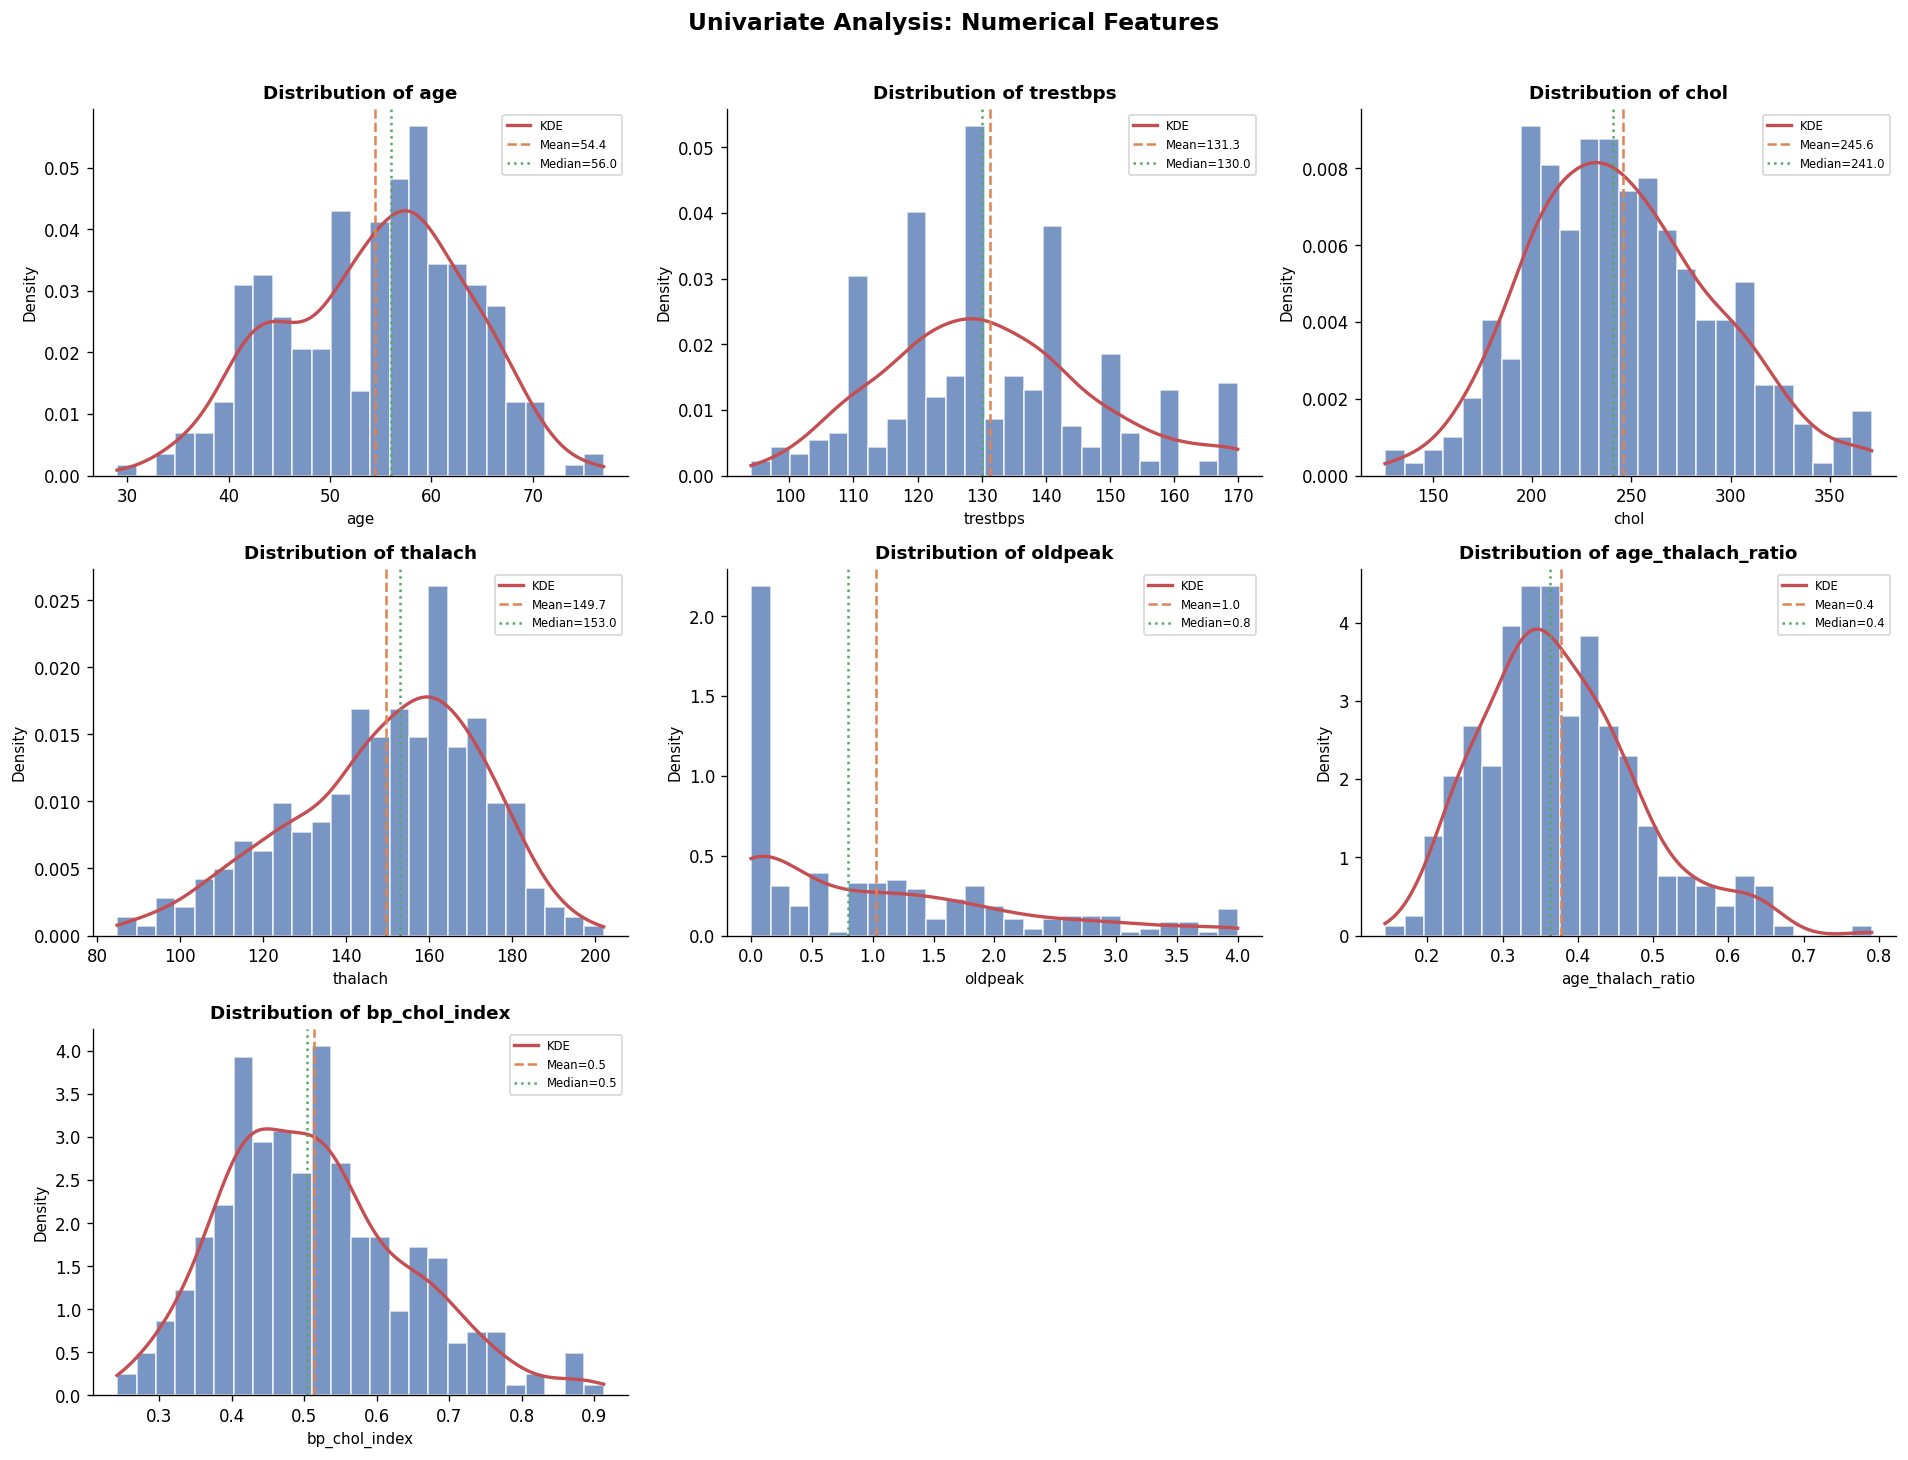

Plot saved: univariate_numerical.png


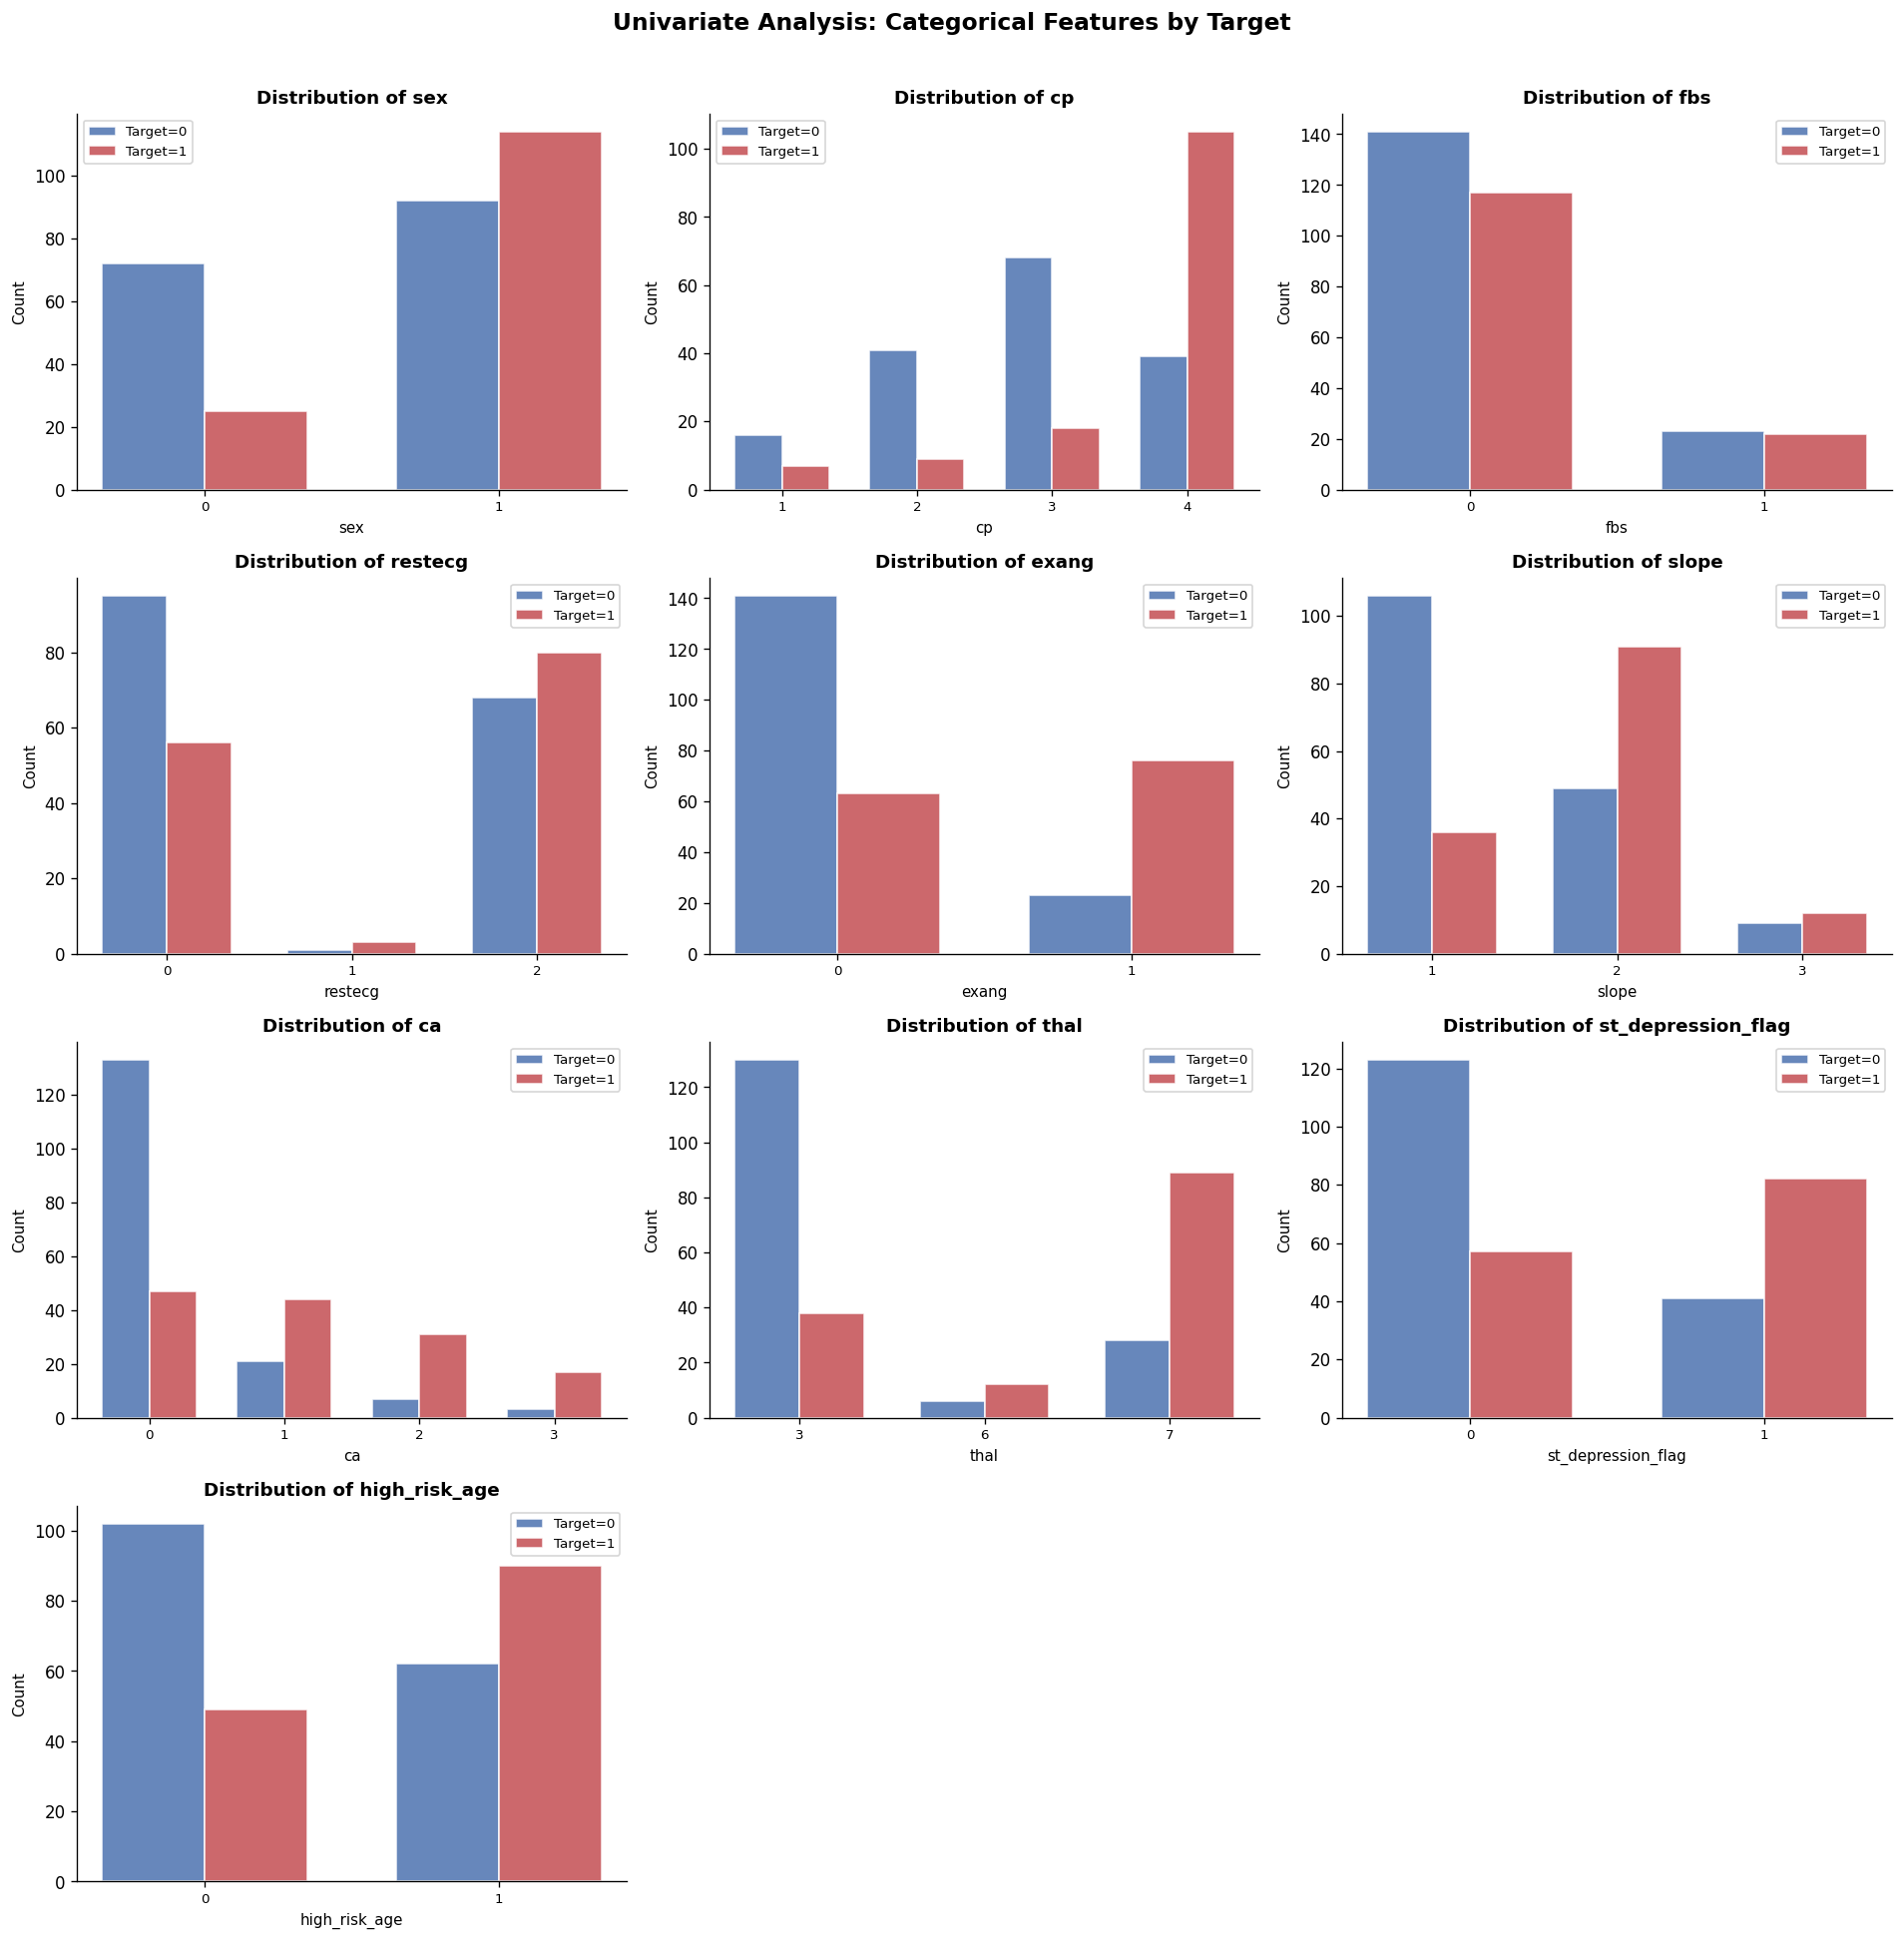

Plot saved: univariate_categorical.png

Skewness and Kurtosis of Numerical Features:
                     Mean    Std  Skewness  Kurtosis
age                54.439  9.039    -0.209    -0.523
trestbps          131.347 16.649     0.383    -0.184
chol              245.584 47.559     0.331    -0.101
thalach           149.653 22.732    -0.493    -0.233
oldpeak             1.024  1.110     0.998     0.123
age_thalach_ratio   0.377  0.106     0.702     0.583
bp_chol_index       0.513  0.127     0.583     0.171


In [7]:
# Cell 7: EDA - Univariate Analysis

def plot_numerical_distributions(df, num_cols, target_col):
    """
    Plot histogram with KDE for each numerical feature.
    Includes mean and median reference lines.
    """
    n     = len(num_cols)
    ncols = 3
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        ax = axes[i]
        data = df[col]

        ax.hist(data, bins=25, color="#4C72B0", edgecolor="white",
                alpha=0.75, density=True)

        from scipy.stats import gaussian_kde
        kde_x = np.linspace(data.min(), data.max(), 300)
        kde   = gaussian_kde(data)
        ax.plot(kde_x, kde(kde_x), color="#C44E52", linewidth=2, label="KDE")

        ax.axvline(data.mean(),   color="#DD8452", linewidth=1.5,
                   linestyle="--", label=f"Mean={data.mean():.1f}")
        ax.axvline(data.median(), color="#55A868", linewidth=1.5,
                   linestyle=":",  label=f"Median={data.median():.1f}")

        ax.set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
        ax.set_xlabel(col, fontsize=9)
        ax.set_ylabel("Density", fontsize=9)
        ax.legend(fontsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Univariate Analysis: Numerical Features",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("univariate_numerical.png", bbox_inches="tight")
    plt.show()
    print("Plot saved: univariate_numerical.png")


def plot_categorical_distributions(df, cat_cols, target_col):
    """
    Plot count bar charts for each categorical feature,
    split by target class.
    """
    n     = len(cat_cols)
    ncols = 3
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
    axes = axes.flatten()

    palette = {0: "#4C72B0", 1: "#C44E52"}

    for i, col in enumerate(cat_cols):
        ax = axes[i]
        ct = df.groupby([col, target_col]).size().reset_index(name="count")

        categories  = sorted(df[col].unique())
        target_vals = sorted(df[target_col].unique())
        x           = np.arange(len(categories))
        width       = 0.35

        for j, tv in enumerate(target_vals):
            subset = ct[ct[target_col] == tv]
            counts = [subset[subset[col] == c]["count"].values[0]
                      if c in subset[col].values else 0
                      for c in categories]
            ax.bar(x + j * width, counts, width,
                   label=f"Target={tv}",
                   color=palette[tv], alpha=0.85, edgecolor="white")

        ax.set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
        ax.set_xlabel(col, fontsize=9)
        ax.set_ylabel("Count", fontsize=9)
        ax.set_xticks(x + width / 2)
        ax.set_xticklabels(categories, fontsize=8)
        ax.legend(fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Univariate Analysis: Categorical Features by Target",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("univariate_categorical.png", bbox_inches="tight")
    plt.show()
    print("Plot saved: univariate_categorical.png")


def print_univariate_stats(df, num_cols):
    """Print skewness and kurtosis for numerical columns."""
    print("\nSkewness and Kurtosis of Numerical Features:")
    stats_df = pd.DataFrame({
        "Mean"    : df[num_cols].mean().round(3),
        "Std"     : df[num_cols].std().round(3),
        "Skewness": df[num_cols].skew().round(3),
        "Kurtosis": df[num_cols].kurt().round(3)
    })
    print(stats_df)


# ------------------------------------------------------------------ #
# EXECUTE UNIVARIATE ANALYSIS
# ------------------------------------------------------------------ #

num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak",
            "age_thalach_ratio", "bp_chol_index"]

cat_cols = ["sex", "cp", "fbs", "restecg", "exang",
            "slope", "ca", "thal", "st_depression_flag", "high_risk_age"]

plot_numerical_distributions(df, num_cols, "target")
plot_categorical_distributions(df, cat_cols, "target")
print_univariate_stats(df, num_cols)

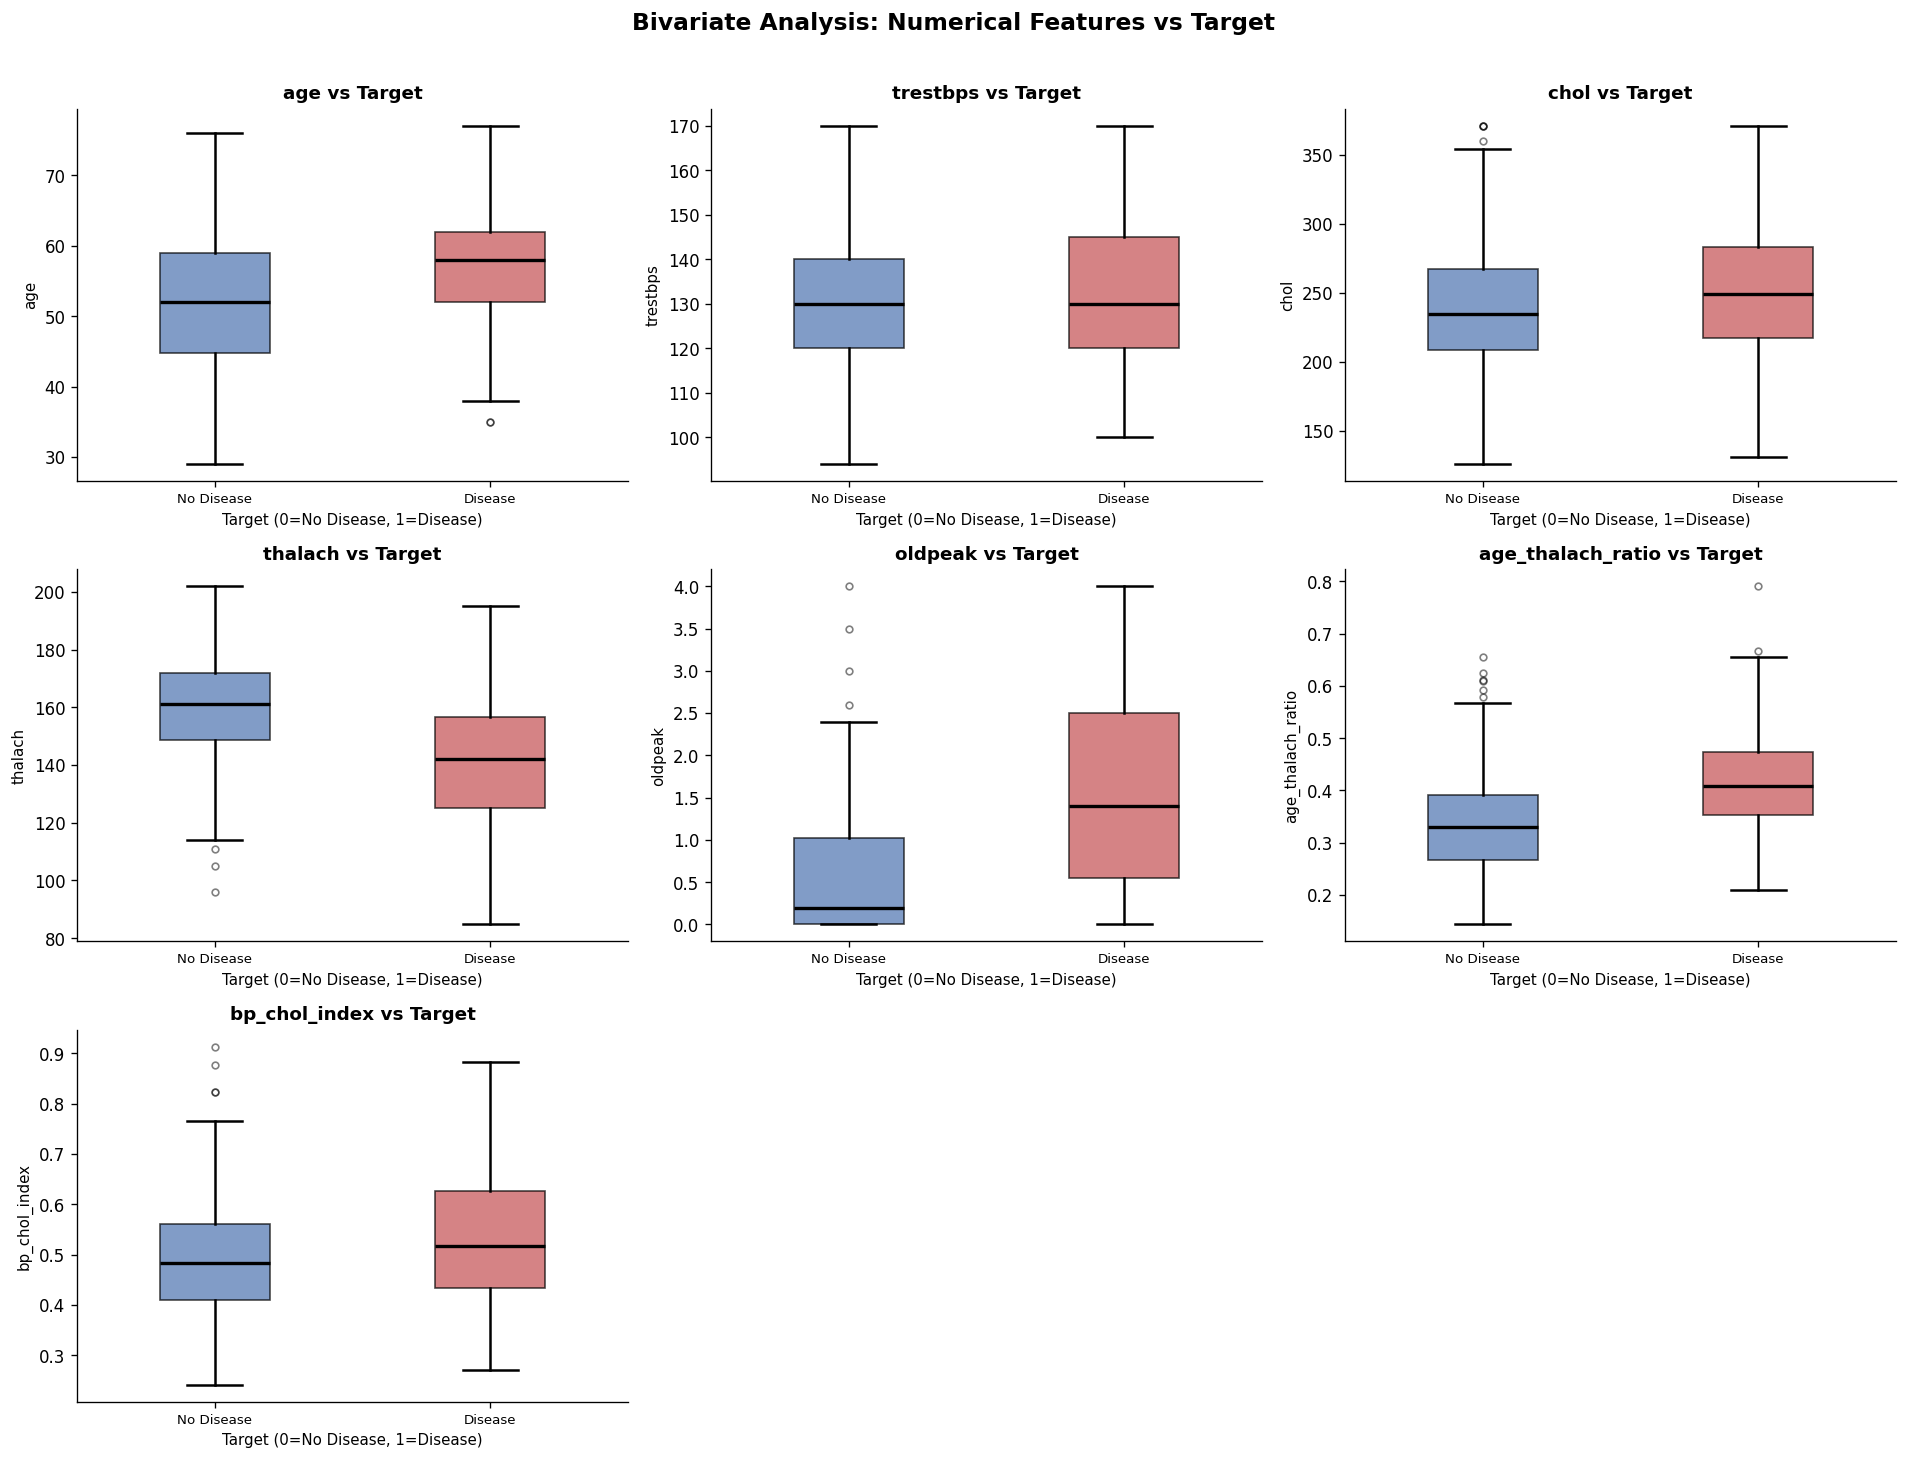

Plot saved: bivariate_boxplot.png


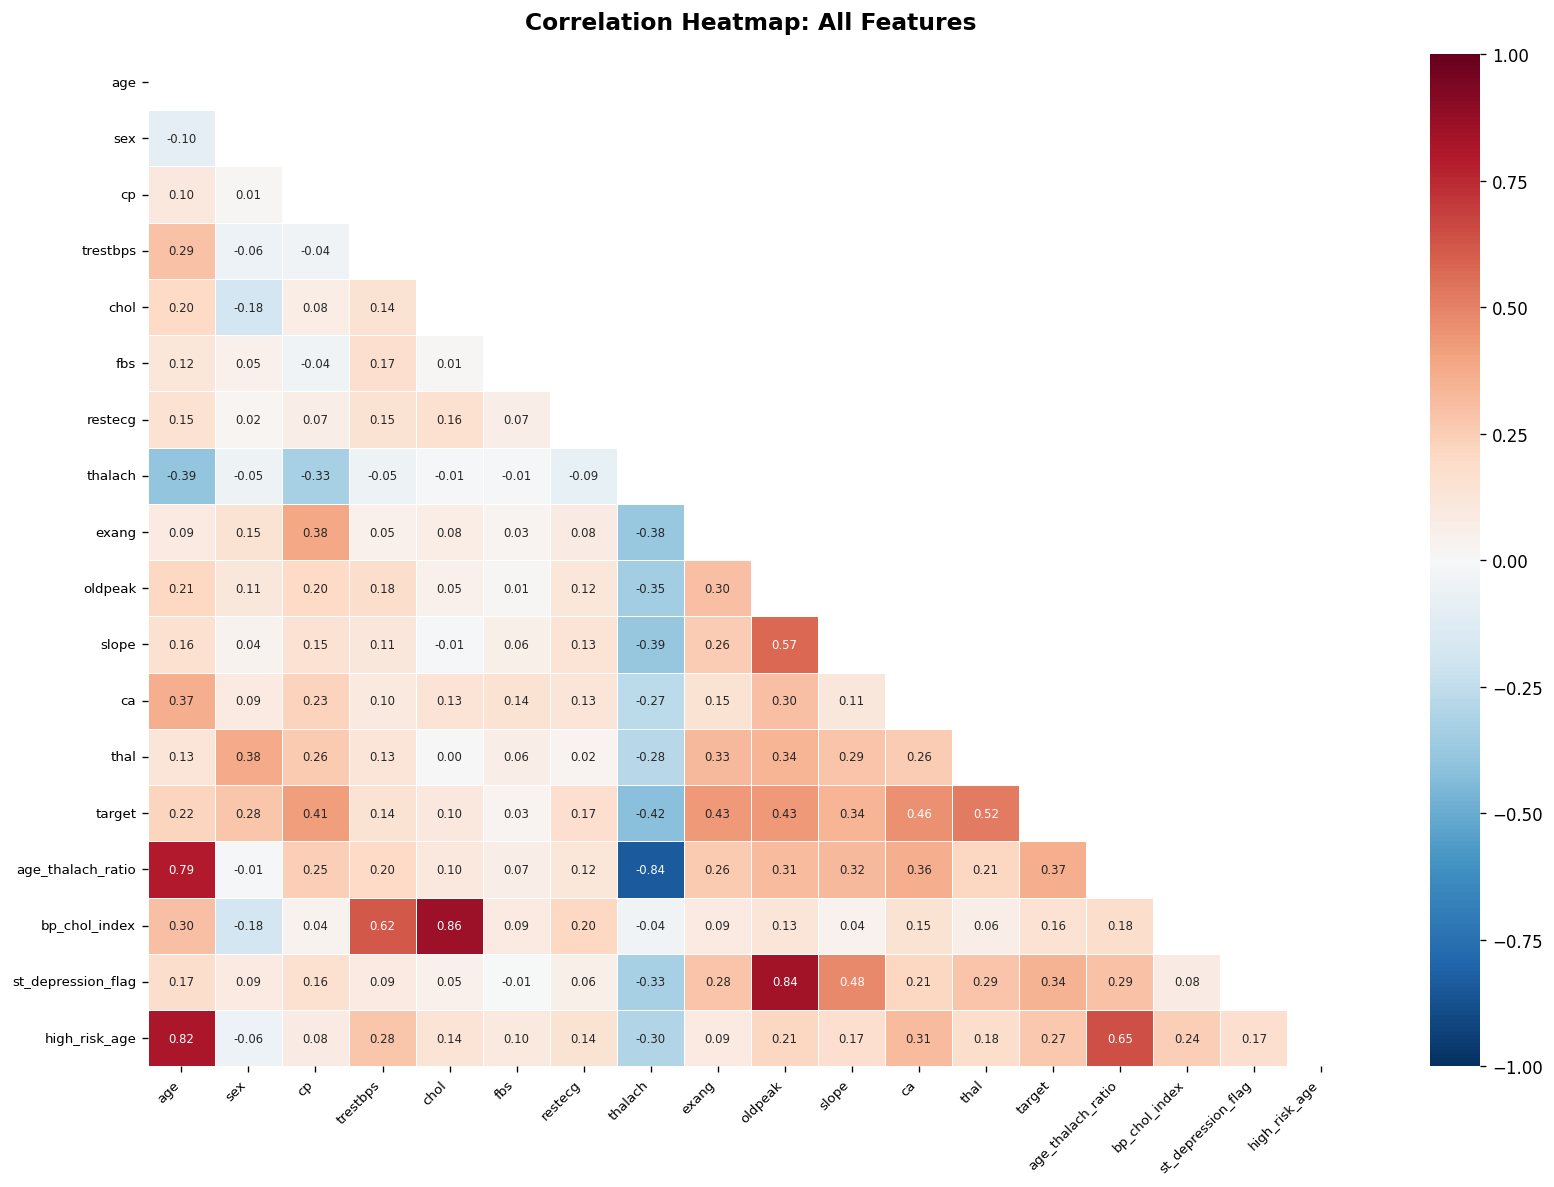

Plot saved: correlation_heatmap.png


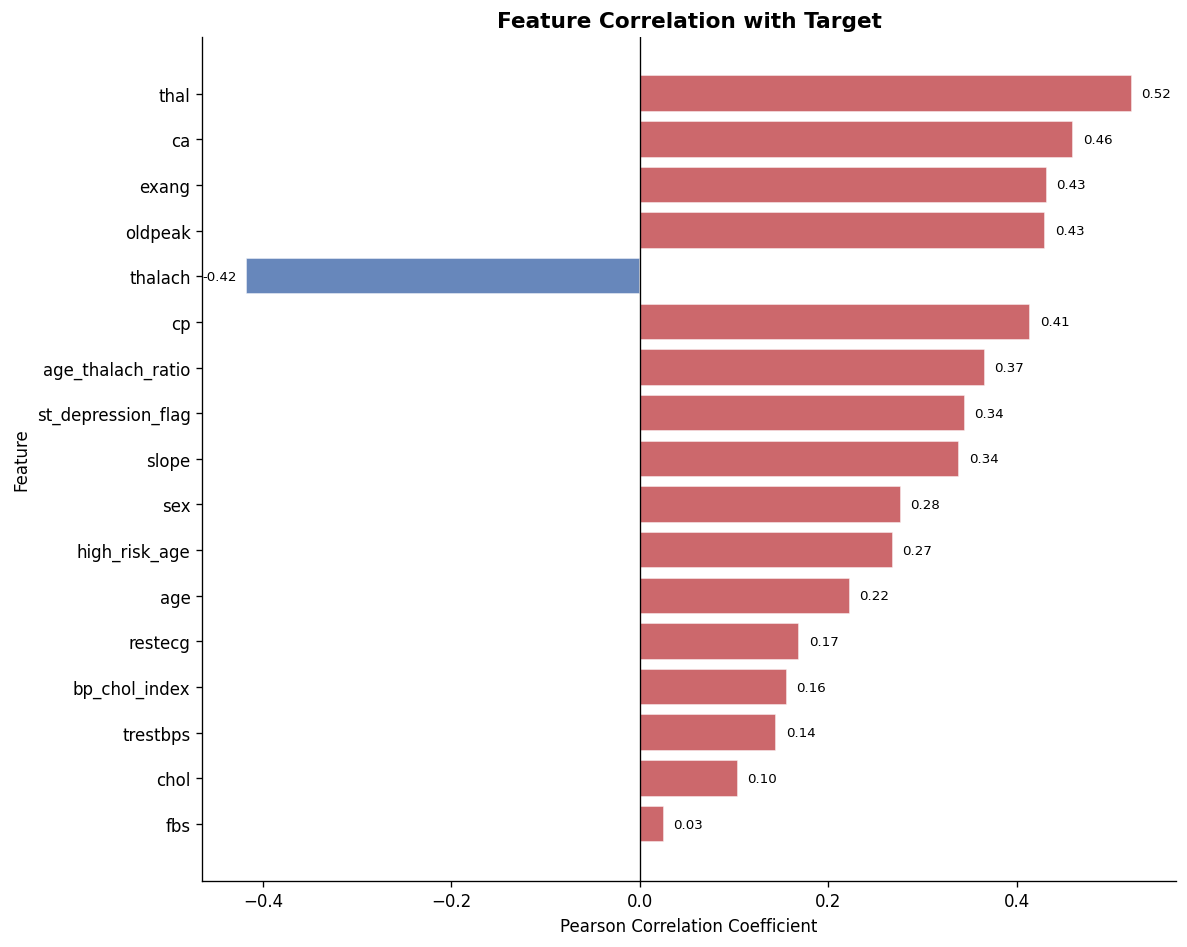

Plot saved: target_correlation_bar.png

Group Means by Target Class:
target                  0       1
age                52.585  56.626
trestbps          129.128 133.964
chol              241.043 250.942
thalach           158.378 139.358
oldpeak             0.585   1.542
age_thalach_ratio   0.342   0.419
bp_chol_index       0.495   0.535


In [8]:
# Cell 8: EDA - Bivariate Analysis

def plot_feature_vs_target_box(df, num_cols, target_col):
    """
    Boxplots of each numerical feature split by target class.
    Reveals distributional differences between disease and no-disease groups.
    """
    n     = len(num_cols)
    ncols = 3
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
    axes = axes.flatten()

    palette = {0: "#4C72B0", 1: "#C44E52"}

    for i, col in enumerate(num_cols):
        ax = axes[i]
        for tv, color in palette.items():
            data = df[df[target_col] == tv][col]
            bp   = ax.boxplot(data, positions=[tv], widths=0.4,
                              patch_artist=True,
                              boxprops=dict(facecolor=color, alpha=0.7),
                              medianprops=dict(color="black", linewidth=2),
                              whiskerprops=dict(linewidth=1.5),
                              capprops=dict(linewidth=1.5),
                              flierprops=dict(marker="o", markersize=4,
                                             alpha=0.5, color=color))

        ax.set_title(f"{col} vs Target", fontsize=11, fontweight="bold")
        ax.set_xlabel("Target (0=No Disease, 1=Disease)", fontsize=9)
        ax.set_ylabel(col, fontsize=9)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["No Disease", "Disease"], fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Bivariate Analysis: Numerical Features vs Target",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("bivariate_boxplot.png", bbox_inches="tight")
    plt.show()
    print("Plot saved: bivariate_boxplot.png")


def plot_correlation_heatmap(df, target_col):
    """
    Full correlation heatmap of all features including target.
    Highlights strong positive and negative correlations.
    """
    corr = df.corr()

    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(14, 10))
    sns.heatmap(
        corr, mask=mask, annot=True, fmt=".2f",
        cmap="RdBu_r", center=0, vmin=-1, vmax=1,
        linewidths=0.5, linecolor="white",
        annot_kws={"size": 7}, ax=ax
    )
    ax.set_title("Correlation Heatmap: All Features",
                 fontsize=14, fontweight="bold", pad=15)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.savefig("correlation_heatmap.png", bbox_inches="tight")
    plt.show()
    print("Plot saved: correlation_heatmap.png")


def plot_target_correlation_bar(df, target_col):
    """
    Horizontal bar chart of feature correlations with target.
    Sorted by absolute correlation value.
    """
    corr_with_target = df.corr()[target_col].drop(target_col)
    corr_sorted      = corr_with_target.reindex(
        corr_with_target.abs().sort_values(ascending=True).index
    )

    colors = ["#C44E52" if v > 0 else "#4C72B0" for v in corr_sorted]

    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(corr_sorted.index, corr_sorted.values,
                   color=colors, edgecolor="white", alpha=0.85)

    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title("Feature Correlation with Target",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Pearson Correlation Coefficient", fontsize=10)
    ax.set_ylabel("Feature", fontsize=10)

    for bar, val in zip(bars, corr_sorted.values):
        ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}", va="center",
                ha="left" if val >= 0 else "right", fontsize=8)

    plt.tight_layout()
    plt.savefig("target_correlation_bar.png", bbox_inches="tight")
    plt.show()
    print("Plot saved: target_correlation_bar.png")


def print_group_means(df, num_cols, target_col):
    """Print mean values of numerical features grouped by target class."""
    print("\nGroup Means by Target Class:")
    print(df.groupby(target_col)[num_cols].mean().round(3).T)


# ------------------------------------------------------------------ #
# EXECUTE BIVARIATE ANALYSIS
# ------------------------------------------------------------------ #

num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak",
            "age_thalach_ratio", "bp_chol_index"]

plot_feature_vs_target_box(df, num_cols, "target")
plot_correlation_heatmap(df, "target")
plot_target_correlation_bar(df, "target")
print_group_means(df, num_cols, "target")

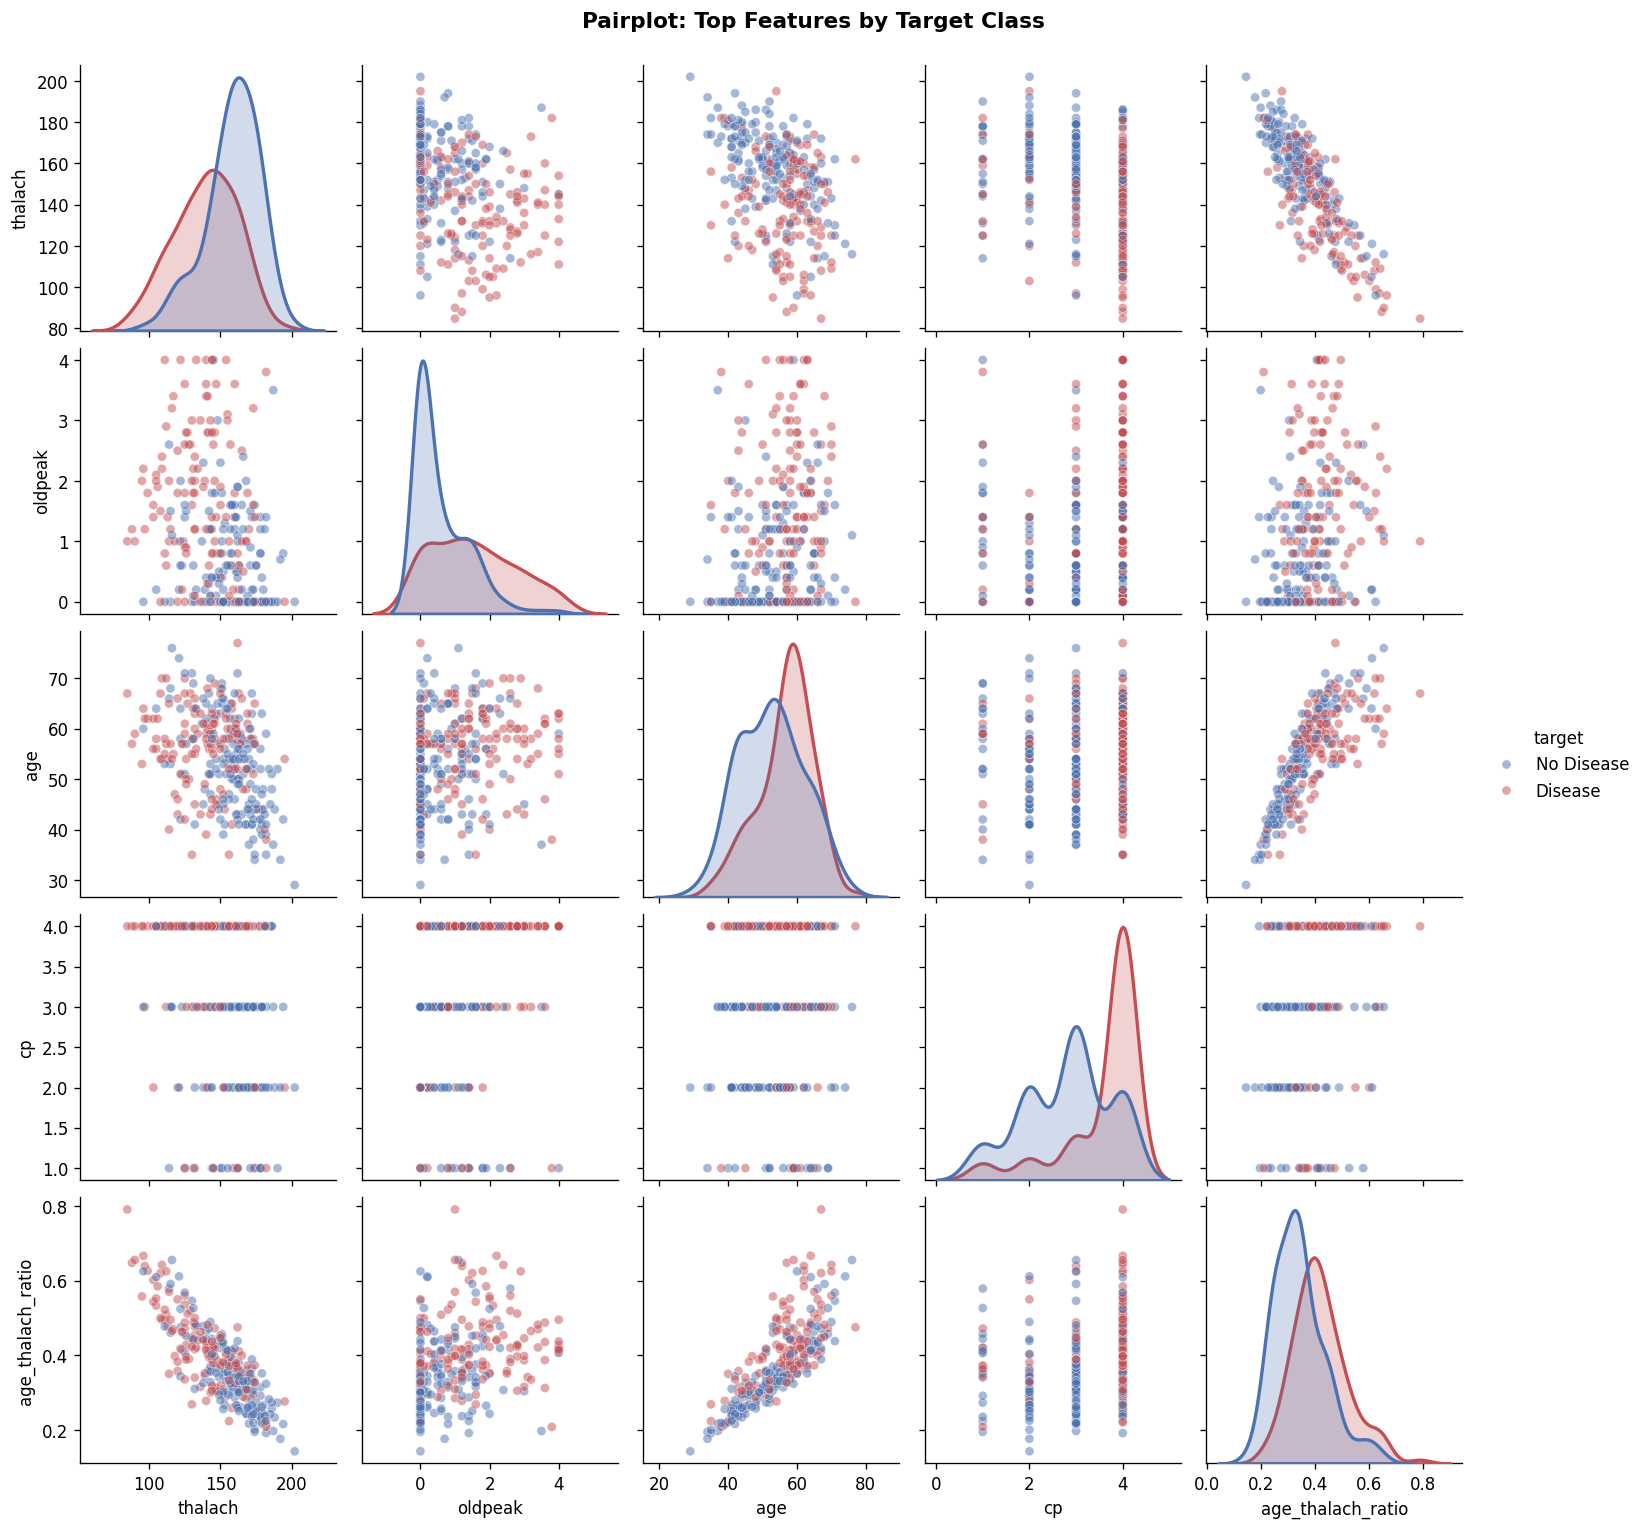

Plot saved: multivariate_pairplot.png


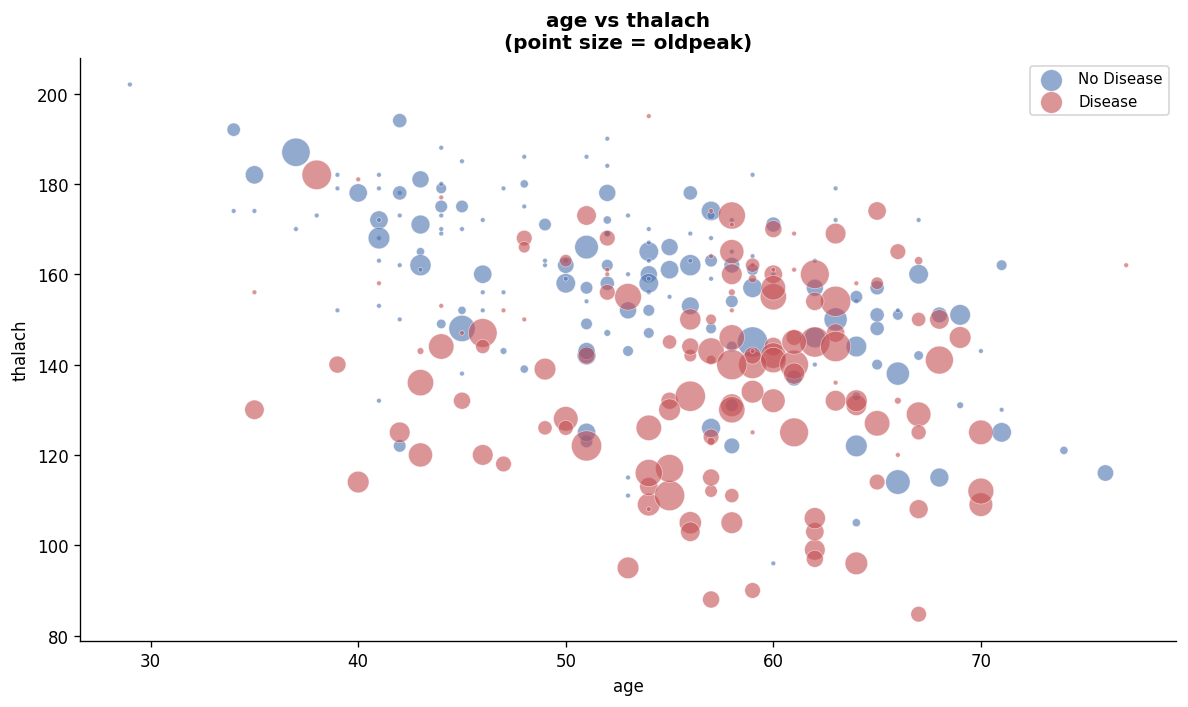

Plot saved: multivariate_scatter.png


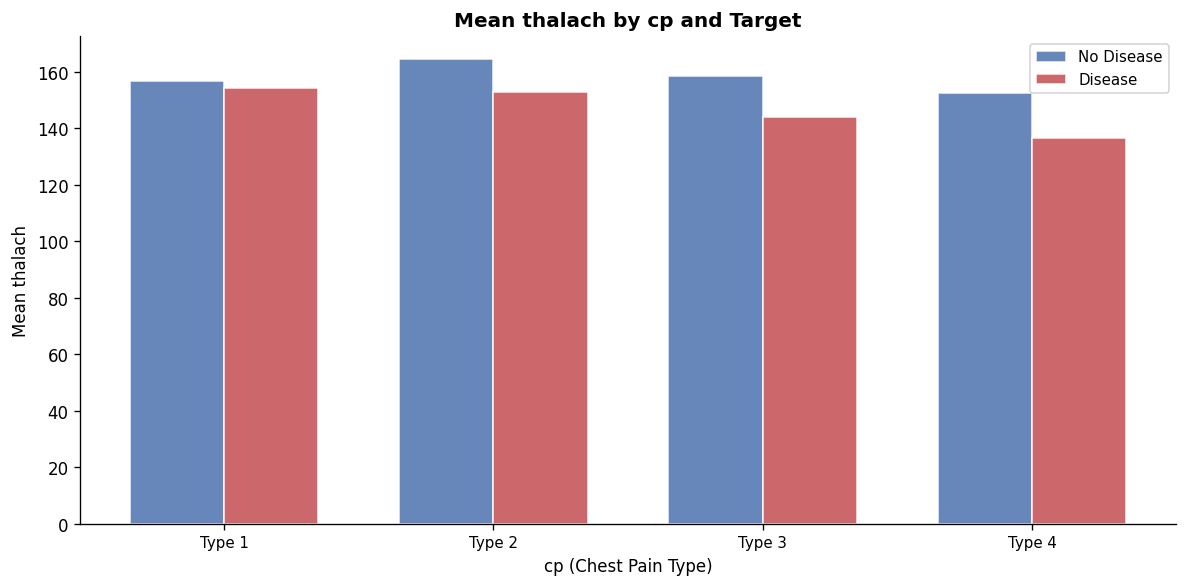

Plot saved: multivariate_grouped_bar.png


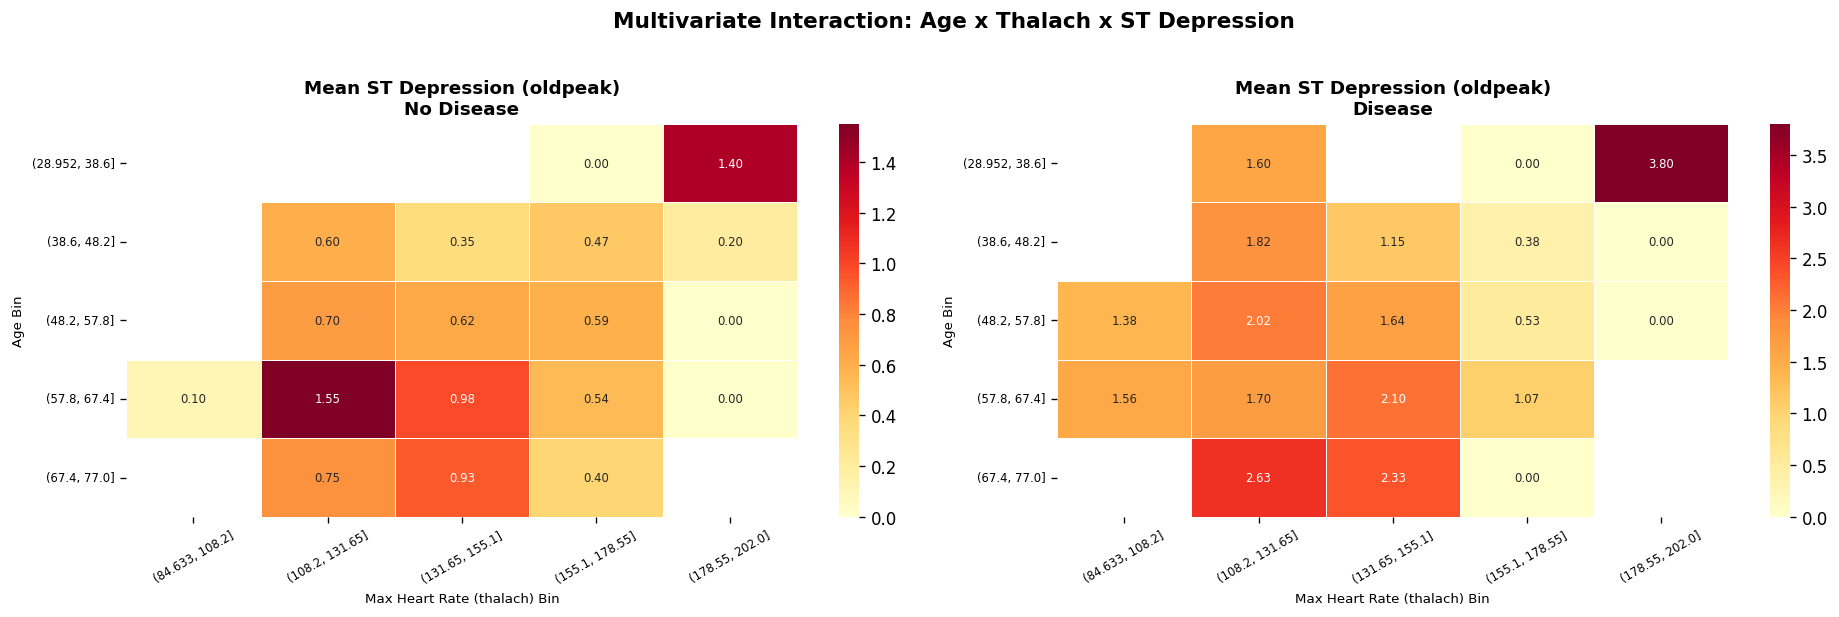

Plot saved: multivariate_heatmap_3way.png

KEY INSIGHTS FROM MULTIVARIATE ANALYSIS

Insight 1: Mean max heart rate (thalach)
  No Disease : 158.4 bpm
  Disease    : 139.4 bpm
  Patients with disease have significantly lower thalach.

Insight 2: Mean ST depression (oldpeak)
  No Disease : 0.585
  Disease    : 1.542
  Higher ST depression strongly associated with disease.

Insight 3: Disease rate by chest pain type (cp)
cp
1   0.304
2   0.180
3   0.209
4   0.729
  Chest pain type 4 (asymptomatic) has highest disease rate.

Insight 4: Mean age_thalach_ratio
  No Disease : 0.342
  Disease    : 0.419
  Higher ratio (older age, lower heart rate) predicts disease.

Insight 5: Disease rate by exercise-induced angina (exang)
exang
0   0.309
1   0.768
  Exercise-induced angina nearly doubles disease probability.


In [9]:
# Cell 9: EDA - Multivariate Analysis

def plot_pairplot_top_features(df, top_features, target_col):
    """
    Pairplot of top correlated features coloured by target class.
    Reveals interaction patterns and separability between classes.
    """
    plot_df = df[top_features + [target_col]].copy()
    plot_df[target_col] = plot_df[target_col].map(
        {0: "No Disease", 1: "Disease"}
    )

    g = sns.pairplot(
        plot_df,
        hue=target_col,
        palette={"No Disease": "#4C72B0", "Disease": "#C44E52"},
        diag_kind="kde",
        plot_kws={"alpha": 0.5, "s": 30},
        diag_kws={"linewidth": 2}
    )
    g.fig.suptitle("Pairplot: Top Features by Target Class",
                   fontsize=13, fontweight="bold", y=1.02)
    plt.savefig("multivariate_pairplot.png", bbox_inches="tight")
    plt.show()
    print("Plot saved: multivariate_pairplot.png")


def plot_scatter_interaction(df, x_col, y_col, hue_col, size_col, target_col):
    """
    Scatter plot showing interaction between two strong predictors,
    with a third feature encoded as point size and target as colour.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    for tv, color, label in zip([0, 1],
                                  ["#4C72B0", "#C44E52"],
                                  ["No Disease", "Disease"]):
        subset = df[df[target_col] == tv]
        sizes  = (subset[size_col] - subset[size_col].min() + 0.1) * 80
        ax.scatter(subset[x_col], subset[y_col],
                   c=color, s=sizes, alpha=0.6,
                   label=label, edgecolors="white", linewidth=0.4)

    ax.set_title(f"{x_col} vs {y_col}\n(point size = {size_col})",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel(x_col, fontsize=10)
    ax.set_ylabel(y_col, fontsize=10)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig("multivariate_scatter.png", bbox_inches="tight")
    plt.show()
    print("Plot saved: multivariate_scatter.png")


def plot_mean_feature_by_cp_and_target(df, feature, group_col, target_col):
    """
    Grouped bar chart showing mean of a feature
    across chest pain types split by target.
    Reveals how categorical and numerical features interact with disease.
    """
    grouped = df.groupby([group_col, target_col])[feature].mean().reset_index()

    categories  = sorted(df[group_col].unique())
    target_vals = sorted(df[target_col].unique())
    x           = np.arange(len(categories))
    width       = 0.35

    palette = {0: "#4C72B0", 1: "#C44E52"}
    labels  = {0: "No Disease", 1: "Disease"}

    fig, ax = plt.subplots(figsize=(10, 5))
    for j, tv in enumerate(target_vals):
        subset = grouped[grouped[target_col] == tv]
        means  = [subset[subset[group_col] == c][feature].values[0]
                  if c in subset[group_col].values else 0
                  for c in categories]
        ax.bar(x + j * width, means, width,
               label=labels[tv], color=palette[tv],
               alpha=0.85, edgecolor="white")

    ax.set_title(f"Mean {feature} by {group_col} and Target",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel(f"{group_col} (Chest Pain Type)", fontsize=10)
    ax.set_ylabel(f"Mean {feature}", fontsize=10)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels([f"Type {c}" for c in categories], fontsize=9)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig("multivariate_grouped_bar.png", bbox_inches="tight")
    plt.show()
    print("Plot saved: multivariate_grouped_bar.png")


def plot_age_thalach_oldpeak_3d_proxy(df, target_col):
    """
    Heatmap proxy for 3D interaction: age bins vs thalach bins,
    cell colour = mean oldpeak. Separate panels per target class.
    """
    df2         = df.copy()
    df2["age_bin"]     = pd.cut(df2["age"], bins=5)
    df2["thalach_bin"] = pd.cut(df2["thalach"], bins=5)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    titles    = {0: "No Disease", 1: "Disease"}

    for ax, tv in zip(axes, [0, 1]):
        subset = df2[df2[target_col] == tv]
        pivot  = subset.pivot_table(
            values="oldpeak",
            index="age_bin",
            columns="thalach_bin",
            aggfunc="mean"
        )
        sns.heatmap(pivot, ax=ax, cmap="YlOrRd", annot=True,
                    fmt=".2f", linewidths=0.5, linecolor="white",
                    annot_kws={"size": 7})
        ax.set_title(f"Mean ST Depression (oldpeak)\n{titles[tv]}",
                     fontsize=11, fontweight="bold")
        ax.set_xlabel("Max Heart Rate (thalach) Bin", fontsize=8)
        ax.set_ylabel("Age Bin", fontsize=8)
        ax.tick_params(axis="x", rotation=30, labelsize=7)
        ax.tick_params(axis="y", rotation=0,  labelsize=7)

    plt.suptitle("Multivariate Interaction: Age x Thalach x ST Depression",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("multivariate_heatmap_3way.png", bbox_inches="tight")
    plt.show()
    print("Plot saved: multivariate_heatmap_3way.png")


def print_multivariate_insights(df, target_col):
    """Print 5 key statistical insights derived from multivariate analysis."""
    print("\n" + "=" * 60)
    print("KEY INSIGHTS FROM MULTIVARIATE ANALYSIS")
    print("=" * 60)

    # Insight 1
    mean_thalach = df.groupby(target_col)["thalach"].mean()
    print(f"\nInsight 1: Mean max heart rate (thalach)")
    print(f"  No Disease : {mean_thalach[0]:.1f} bpm")
    print(f"  Disease    : {mean_thalach[1]:.1f} bpm")
    print(f"  Patients with disease have significantly lower thalach.")

    # Insight 2
    mean_oldpeak = df.groupby(target_col)["oldpeak"].mean()
    print(f"\nInsight 2: Mean ST depression (oldpeak)")
    print(f"  No Disease : {mean_oldpeak[0]:.3f}")
    print(f"  Disease    : {mean_oldpeak[1]:.3f}")
    print(f"  Higher ST depression strongly associated with disease.")

    # Insight 3
    cp_disease_rate = df.groupby("cp")["target"].mean().round(3)
    print(f"\nInsight 3: Disease rate by chest pain type (cp)")
    print(cp_disease_rate.to_string())
    print(f"  Chest pain type 4 (asymptomatic) has highest disease rate.")

    # Insight 4
    ratio_means = df.groupby(target_col)["age_thalach_ratio"].mean()
    print(f"\nInsight 4: Mean age_thalach_ratio")
    print(f"  No Disease : {ratio_means[0]:.3f}")
    print(f"  Disease    : {ratio_means[1]:.3f}")
    print(f"  Higher ratio (older age, lower heart rate) predicts disease.")

    # Insight 5
    exang_rate = df.groupby("exang")["target"].mean().round(3)
    print(f"\nInsight 5: Disease rate by exercise-induced angina (exang)")
    print(exang_rate.to_string())
    print(f"  Exercise-induced angina nearly doubles disease probability.")


# ------------------------------------------------------------------ #
# EXECUTE MULTIVARIATE ANALYSIS
# ------------------------------------------------------------------ #

top_features = ["thalach", "oldpeak", "age", "cp", "age_thalach_ratio"]

plot_pairplot_top_features(df, top_features, "target")
plot_scatter_interaction(df, "age", "thalach", "cp", "oldpeak", "target")
plot_mean_feature_by_cp_and_target(df, "thalach", "cp", "target")
plot_age_thalach_oldpeak_3d_proxy(df, "target")
print_multivariate_insights(df, "target")

In [10]:
# Cell 10: Feature Selection

def compute_correlation_selection(df, target_col, threshold=0.1):
    """
    Select features based on absolute Pearson correlation with target.
    Features with correlation below threshold are flagged for removal.
    """
    corr         = df.corr()[target_col].drop(target_col)
    corr_abs     = corr.abs().sort_values(ascending=False)
    selected     = corr_abs[corr_abs >= threshold].index.tolist()
    dropped      = corr_abs[corr_abs < threshold].index.tolist()

    print("Correlation with Target (absolute, sorted):")
    print(corr_abs.round(3).to_string())
    print(f"\nThreshold : {threshold}")
    print(f"Selected  : {selected}")
    print(f"Dropped   : {dropped}")
    return selected


def compute_vif(df, feature_cols):
    """
    Compute Variance Inflation Factor for each feature.
    VIF > 10 indicates severe multicollinearity.
    VIF > 5  indicates moderate multicollinearity.
    """
    X      = df[feature_cols].copy()
    X      = X.assign(const=1)
    vif_df = pd.DataFrame()
    vif_df["Feature"] = feature_cols
    vif_df["VIF"]     = [
        variance_inflation_factor(X.values, i)
        for i in range(len(feature_cols))
    ]
    vif_df = vif_df.sort_values("VIF", ascending=False).reset_index(drop=True)
    return vif_df


def drop_high_vif(vif_df, threshold=10.0):
    """
    Return list of features to drop based on VIF threshold.
    Drops highest VIF feature iteratively in concept;
    here returns all above threshold for transparency.
    """
    high_vif = vif_df[vif_df["VIF"] > threshold]["Feature"].tolist()
    keep     = vif_df[vif_df["VIF"] <= threshold]["Feature"].tolist()
    print(f"\nVIF threshold : {threshold}")
    print(f"Drop (VIF>10) : {high_vif}")
    print(f"Keep          : {keep}")
    return keep


def rfe_selection(X, y, n_features=10):
    """
    Recursive Feature Elimination using Logistic Regression.
    Returns ranked feature importance dataframe and selected features.
    """
    scaler  = StandardScaler()
    X_sc    = scaler.fit_transform(X)

    estimator = LogisticRegression(max_iter=1000, random_state=42)
    rfe       = RFE(estimator, n_features_to_select=n_features)
    rfe.fit(X_sc, y)

    rfe_df = pd.DataFrame({
        "Feature"  : X.columns,
        "Selected" : rfe.support_,
        "Rank"     : rfe.ranking_
    }).sort_values("Rank")

    selected = rfe_df[rfe_df["Selected"]]["Feature"].tolist()
    print("\nRFE Feature Ranking:")
    print(rfe_df.to_string(index=False))
    print(f"\nRFE Selected Features ({n_features}): {selected}")
    return selected


def final_feature_selection(corr_selected, vif_kept, rfe_selected):
    """
    Consolidate selections from all three methods.
    Final set = features selected by at least 2 out of 3 methods.
    """
    from collections import Counter
    all_features = corr_selected + vif_kept + rfe_selected
    counts       = Counter(all_features)

    final = [f for f, c in counts.items() if c >= 2]
    print("\nFeature vote counts (selected by N methods):")
    for f, c in sorted(counts.items(), key=lambda x: -x[1]):
        print(f"  {f:<25} : {c}/3 methods")
    print(f"\nFinal selected features (>= 2 votes): {final}")
    return final


# ------------------------------------------------------------------ #
# EXECUTE FEATURE SELECTION
# ------------------------------------------------------------------ #

target_col   = "target"
all_features = [c for c in df.columns if c != target_col]
X_all        = df[all_features]
y            = df[target_col]

print("=" * 60)
print("STEP 1: CORRELATION-BASED SELECTION")
print("=" * 60)
corr_selected = compute_correlation_selection(df, target_col, threshold=0.1)

print("\n" + "=" * 60)
print("STEP 2: VARIANCE INFLATION FACTOR (VIF)")
print("=" * 60)
vif_df = compute_vif(df, all_features)
print(vif_df.to_string(index=False))
vif_kept = drop_high_vif(vif_df, threshold=10.0)

print("\n" + "=" * 60)
print("STEP 3: RECURSIVE FEATURE ELIMINATION (RFE)")
print("=" * 60)
rfe_selected = rfe_selection(X_all, y, n_features=10)

print("\n" + "=" * 60)
print("STEP 4: FINAL CONSOLIDATED FEATURE SELECTION")
print("=" * 60)
final_features = final_feature_selection(corr_selected, vif_kept, rfe_selected)

print(f"\nFinal feature count : {len(final_features)}")
print(f"Final features      : {final_features}")

STEP 1: CORRELATION-BASED SELECTION
Correlation with Target (absolute, sorted):
thal                 0.522
ca                   0.460
exang                0.432
oldpeak              0.430
thalach              0.418
cp                   0.414
age_thalach_ratio    0.366
st_depression_flag   0.345
slope                0.339
sex                  0.277
high_risk_age        0.269
age                  0.223
restecg              0.169
bp_chol_index        0.156
trestbps             0.145
chol                 0.104
fbs                  0.025

Threshold : 0.1
Selected  : ['thal', 'ca', 'exang', 'oldpeak', 'thalach', 'cp', 'age_thalach_ratio', 'st_depression_flag', 'slope', 'sex', 'high_risk_age', 'age', 'restecg', 'bp_chol_index', 'trestbps', 'chol']
Dropped   : ['fbs']

STEP 2: VARIANCE INFLATION FACTOR (VIF)
           Feature     VIF
     bp_chol_index 113.024
              chol  70.365
          trestbps  31.543
 age_thalach_ratio  28.229
           thalach  13.529
               age  11.074

In [11]:
# Cell 11: Train/Test Split and Feature Scaling

def prepare_train_test(df, feature_cols, target_col, test_size=0.2, random_state=42):
    """
    Split dataset into train and test sets using stratified sampling.
    Stratification ensures class balance is preserved in both splits.
    """
    X = df[feature_cols]
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    print("Train/Test Split Summary:")
    print(f"  Total samples  : {len(df)}")
    print(f"  Training set   : {X_train.shape[0]} rows ({(1-test_size)*100:.0f}%)")
    print(f"  Test set       : {X_test.shape[0]} rows ({test_size*100:.0f}%)")
    print(f"\n  Train target distribution:")
    print(f"    No Disease : {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)")
    print(f"    Disease    : {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)")
    print(f"\n  Test target distribution:")
    print(f"    No Disease : {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)")
    print(f"    Disease    : {(y_test==1).sum()} ({(y_test==1).mean()*100:.1f}%)")

    return X_train, X_test, y_train, y_test


def scale_features(X_train, X_test, num_cols):
    """
    Apply StandardScaler only to numerical columns.
    Categorical and binary columns are left unchanged.
    Scaler is fit on training data only to prevent data leakage.
    Returns scaled arrays as DataFrames and the fitted scaler.
    """
    X_train_scaled = X_train.copy()
    X_test_scaled  = X_test.copy()

    scaler = StandardScaler()

    X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test_scaled[num_cols]  = scaler.transform(X_test[num_cols])

    print("\nFeature Scaling Summary:")
    print(f"  Method          : StandardScaler (zero mean, unit variance)")
    print(f"  Fit on          : Training set only (no data leakage)")
    print(f"  Scaled columns  : {num_cols}")
    print(f"\n  Post-scaling train stats (numerical only):")
    print(X_train_scaled[num_cols].describe().round(3))

    return X_train_scaled, X_test_scaled, scaler


# ------------------------------------------------------------------ #
# EXECUTE SPLIT AND SCALING
# ------------------------------------------------------------------ #

final_features = [
    'thal', 'ca', 'exang', 'oldpeak', 'thalach', 'cp',
    'st_depression_flag', 'slope', 'sex', 'high_risk_age',
    'age', 'restecg', 'bp_chol_index'
]

target_col = "target"

# Numerical columns within final feature set (to be scaled)
num_to_scale = [
    'oldpeak', 'thalach', 'age', 'bp_chol_index'
]

print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)
X_train, X_test, y_train, y_test = prepare_train_test(
    df, final_features, target_col, test_size=0.2, random_state=42
)

print("\n" + "=" * 60)
print("FEATURE SCALING")
print("=" * 60)
X_train_sc, X_test_sc, scaler = scale_features(X_train, X_test, num_to_scale)

print("\nFinal shapes:")
print(f"  X_train : {X_train_sc.shape}")
print(f"  X_test  : {X_test_sc.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  y_test  : {y_test.shape}")

TRAIN / TEST SPLIT
Train/Test Split Summary:
  Total samples  : 303
  Training set   : 242 rows (80%)
  Test set       : 61 rows (20%)

  Train target distribution:
    No Disease : 131 (54.1%)
    Disease    : 111 (45.9%)

  Test target distribution:
    No Disease : 33 (54.1%)
    Disease    : 28 (45.9%)

FEATURE SCALING

Feature Scaling Summary:
  Method          : StandardScaler (zero mean, unit variance)
  Fit on          : Training set only (no data leakage)
  Scaled columns  : ['oldpeak', 'thalach', 'age', 'bp_chol_index']

  Post-scaling train stats (numerical only):
       oldpeak  thalach     age  bp_chol_index
count  242.000  242.000 242.000        242.000
mean     0.000   -0.000  -0.000          0.000
std      1.002    1.002   1.002          1.002
min     -0.928   -2.906  -2.846         -2.128
25%     -0.928   -0.691  -0.729         -0.756
50%     -0.172    0.155   0.162         -0.080
75%      0.584    0.712   0.718          0.633
max      2.851    2.315   2.500          3

MODEL TRAINING AND EVALUATION
  Training: Logistic Regression ...
    Accuracy=0.8852  F1=0.8814  ROC-AUC=0.9491
  Training: Decision Tree ...
    Accuracy=0.7213  F1=0.7302  ROC-AUC=0.7289
  Training: Random Forest ...
    Accuracy=0.8852  F1=0.8814  ROC-AUC=0.9567
  Training: XGBoost ...
    Accuracy=0.8361  F1=0.8333  ROC-AUC=0.9502

MODEL COMPARISON TABLE (BEFORE TUNING)
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC  CV Accuracy
Model                                                                           
Logistic Regression     0.885      0.839   0.929     0.881    0.949        0.839
Decision Tree           0.721      0.657   0.821     0.730    0.729        0.735
Random Forest           0.885      0.839   0.929     0.881    0.957        0.793
XGBoost                 0.836      0.781   0.893     0.833    0.950        0.801


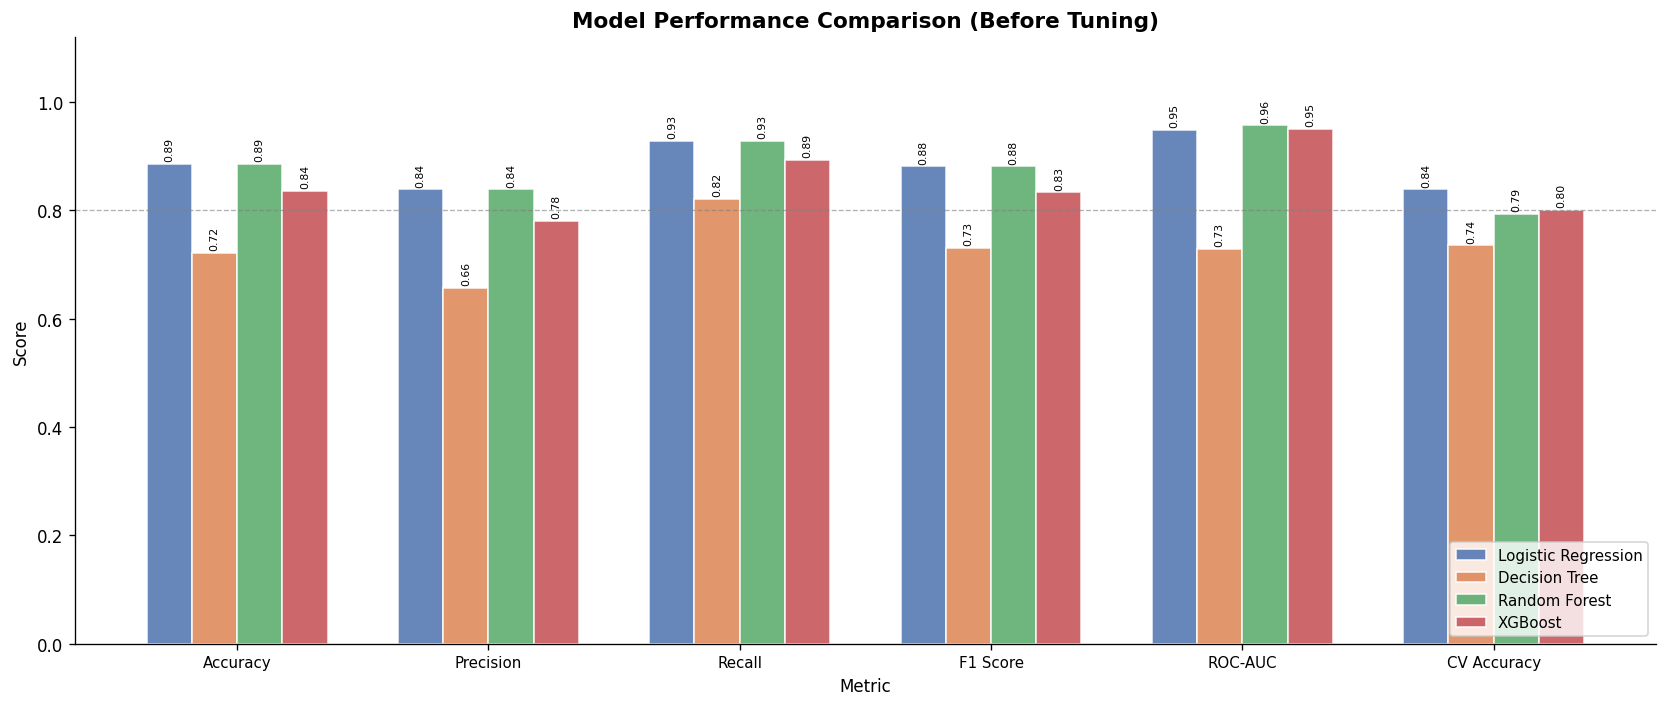

Plot saved: model_comparison_before_tuning.png


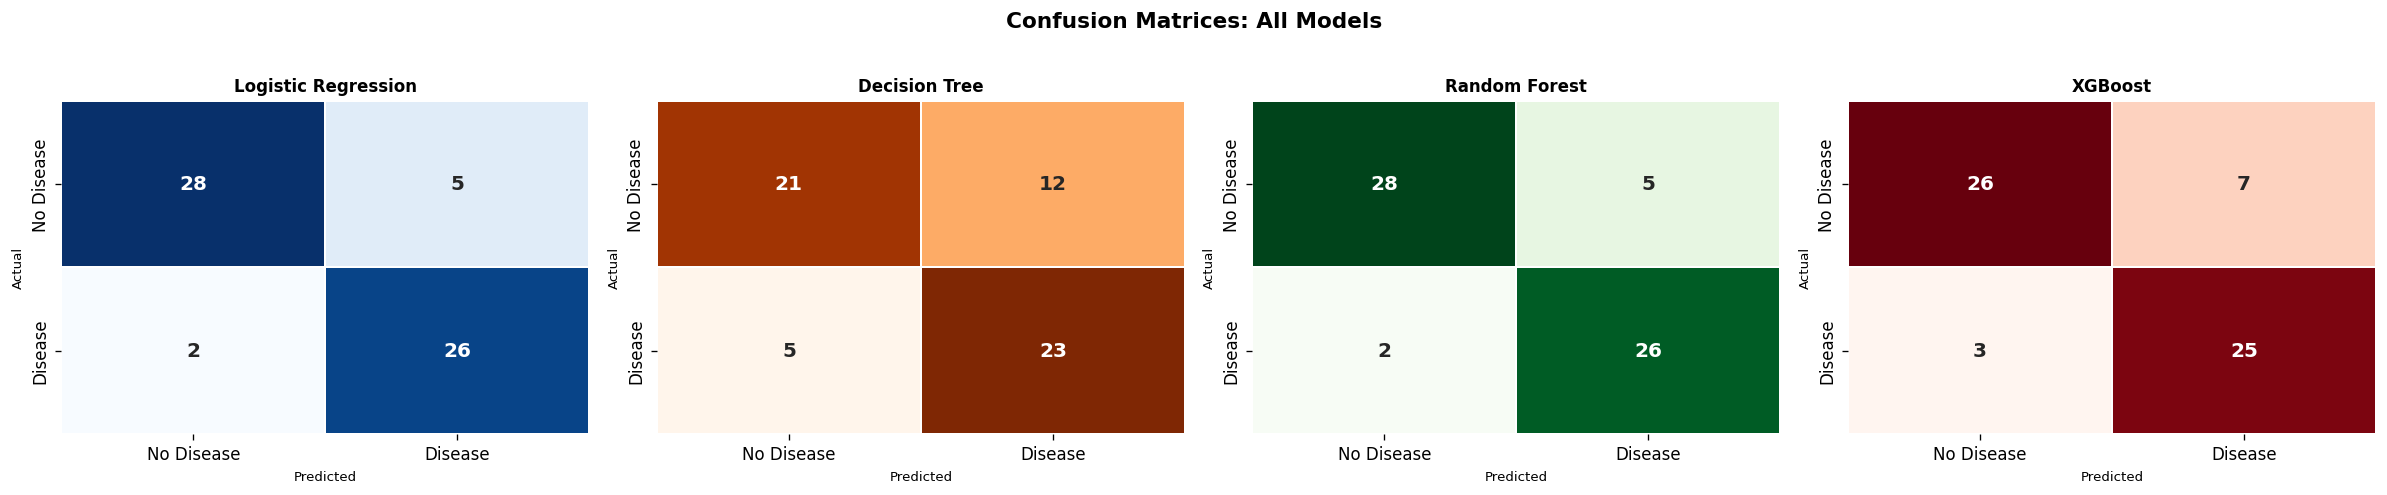

Plot saved: confusion_matrices.png


In [12]:
# Cell 12: Model Training and Comparison

def build_model_pipeline(model, scaler=None):
    """
    Wrap a model in a sklearn Pipeline.
    Scaler is already applied, so no scaler needed here.
    This function exists for extensibility and clean model packaging.
    """
    from sklearn.pipeline import Pipeline
    steps = [("classifier", model)]
    return Pipeline(steps)


def train_and_evaluate(model, X_train, X_test, y_train, y_test, model_name):
    """
    Train a model and return a dictionary of evaluation metrics.
    Metrics: Accuracy, Precision, Recall, F1, ROC-AUC.
    Also returns cross-validation mean accuracy on training set.
    """
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] \
              if hasattr(model, "predict_proba") \
              else model.decision_function(X_test)

    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring="accuracy"
    )

    results = {
        "Model"       : model_name,
        "Accuracy"    : round(accuracy_score(y_test, y_pred), 4),
        "Precision"   : round(precision_score(y_test, y_pred), 4),
        "Recall"      : round(recall_score(y_test, y_pred), 4),
        "F1 Score"    : round(f1_score(y_test, y_pred), 4),
        "ROC-AUC"     : round(roc_auc_score(y_test, y_proba), 4),
        "CV Accuracy" : round(cv_scores.mean(), 4)
    }
    return results, model


def run_all_models(X_train, X_test, y_train, y_test):
    """
    Define, train and evaluate all four classification models.
    Returns comparison dataframe and dictionary of trained models.
    """
    model_definitions = {
        "Logistic Regression": build_model_pipeline(
            LogisticRegression(max_iter=1000, random_state=42)
        ),
        "Decision Tree": build_model_pipeline(
            DecisionTreeClassifier(random_state=42)
        ),
        "Random Forest": build_model_pipeline(
            RandomForestClassifier(n_estimators=100, random_state=42)
        ),
        "XGBoost": build_model_pipeline(
            GradientBoostingClassifier(n_estimators=100, random_state=42)
        )
    }

    all_results   = []
    trained_models = {}

    for name, pipeline in model_definitions.items():
        print(f"  Training: {name} ...")
        result, trained = train_and_evaluate(
            pipeline, X_train, X_test, y_train, y_test, name
        )
        all_results.append(result)
        trained_models[name] = trained
        print(f"    Accuracy={result['Accuracy']}  "
              f"F1={result['F1 Score']}  "
              f"ROC-AUC={result['ROC-AUC']}")

    comparison_df = pd.DataFrame(all_results).set_index("Model")
    return comparison_df, trained_models


def plot_model_comparison(comparison_df):
    """
    Grouped bar chart comparing all models across all metrics.
    """
    metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "CV Accuracy"]
    models  = comparison_df.index.tolist()
    x       = np.arange(len(metrics))
    width   = 0.18
    colors  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

    fig, ax = plt.subplots(figsize=(14, 6))

    for i, (model, color) in enumerate(zip(models, colors)):
        values = [comparison_df.loc[model, m] for m in metrics]
        bars   = ax.bar(x + i * width, values, width,
                        label=model, color=color,
                        alpha=0.85, edgecolor="white")
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f"{val:.2f}", ha="center", va="bottom",
                    fontsize=6.5, rotation=90)

    ax.set_title("Model Performance Comparison (Before Tuning)",
                 fontsize=13, fontweight="bold")
    ax.set_ylabel("Score", fontsize=10)
    ax.set_xlabel("Metric", fontsize=10)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(metrics, fontsize=9)
    ax.set_ylim(0, 1.12)
    ax.legend(fontsize=9, loc="lower right")
    ax.axhline(0.8, color="gray", linewidth=0.8,
               linestyle="--", alpha=0.6, label="0.8 reference")
    plt.tight_layout()
    plt.savefig("model_comparison_before_tuning.png", bbox_inches="tight")
    plt.show()
    print("Plot saved: model_comparison_before_tuning.png")


def plot_confusion_matrices(trained_models, X_test, y_test):
    """
    Plot confusion matrix for each trained model side by side.
    """
    n     = len(trained_models)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))

    colors = ["Blues", "Oranges", "Greens", "Reds"]

    for ax, (name, model), cmap in zip(axes, trained_models.items(), colors):
        y_pred = model.predict(X_test)
        cm     = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                    linewidths=1, linecolor="white",
                    xticklabels=["No Disease", "Disease"],
                    yticklabels=["No Disease", "Disease"],
                    ax=ax, cbar=False,
                    annot_kws={"size": 12, "weight": "bold"})
        ax.set_title(name, fontsize=10, fontweight="bold")
        ax.set_xlabel("Predicted", fontsize=8)
        ax.set_ylabel("Actual", fontsize=8)

    plt.suptitle("Confusion Matrices: All Models",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("confusion_matrices.png", bbox_inches="tight")
    plt.show()
    print("Plot saved: confusion_matrices.png")


# ------------------------------------------------------------------ #
# EXECUTE MODEL TRAINING
# ------------------------------------------------------------------ #

print("=" * 60)
print("MODEL TRAINING AND EVALUATION")
print("=" * 60)

comparison_df, trained_models = run_all_models(
    X_train_sc, X_test_sc, y_train, y_test
)

print("\n" + "=" * 60)
print("MODEL COMPARISON TABLE (BEFORE TUNING)")
print("=" * 60)
print(comparison_df.to_string())

plot_model_comparison(comparison_df)
plot_confusion_matrices(trained_models, X_test_sc, y_test)

HYPERPARAMETER TUNING

Tuning Logistic Regression...
  Best params : {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
  Best CV AUC : 0.9052

Tuning Decision Tree...
  Best params : {'classifier__criterion': 'entropy', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2}
  Best CV AUC : 0.8396

Tuning Random Forest...
  Best params : {'classifier__n_estimators': 300, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'log2', 'classifier__max_depth': 8}
  Best CV AUC : 0.9033

Tuning XGBoost (Gradient Boosting)...
  Best params : {'classifier__subsample': 0.7, 'classifier__n_estimators': 50, 'classifier__min_samples_split': 5, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05}
  Best CV AUC : 0.9032

TUNED MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                             

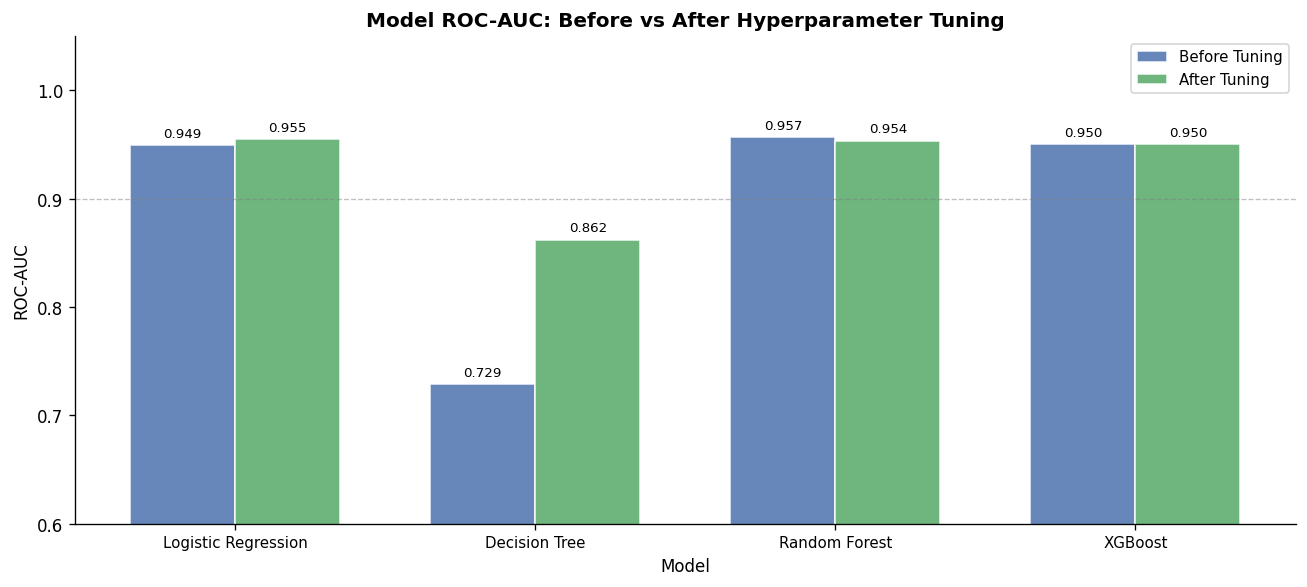

Plot saved: before_after_tuning.png


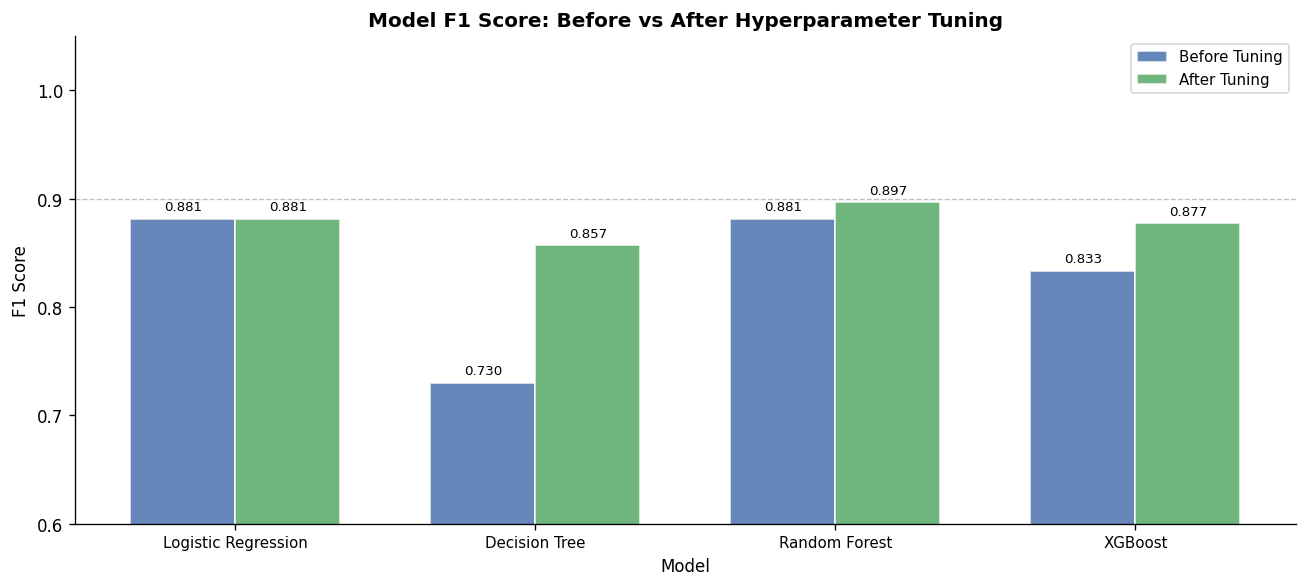

Plot saved: before_after_tuning.png


In [13]:
# Cell 13: Hyperparameter Tuning with GridSearchCV and RandomizedSearchCV

def tune_logistic_regression(X_train, y_train):
    """
    GridSearchCV for Logistic Regression.
    Tunes regularization strength C and penalty type.
    """
    param_grid = {
        "classifier__C"      : [0.01, 0.1, 1, 10, 100],
        "classifier__penalty": ["l1", "l2"],
        "classifier__solver" : ["liblinear"]
    }
    pipeline = build_model_pipeline(
        LogisticRegression(max_iter=1000, random_state=42)
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = GridSearchCV(pipeline, param_grid, cv=cv,
                          scoring="roc_auc", n_jobs=-1, verbose=0)
    search.fit(X_train, y_train)
    print(f"  Best params : {search.best_params_}")
    print(f"  Best CV AUC : {search.best_score_:.4f}")
    return search.best_estimator_


def tune_decision_tree(X_train, y_train):
    """
    GridSearchCV for Decision Tree.
    Tunes max depth, min samples split and min samples leaf.
    """
    param_grid = {
        "classifier__max_depth"       : [3, 4, 5, 6, 8, None],
        "classifier__min_samples_split": [2, 5, 10],
        "classifier__min_samples_leaf" : [1, 2, 4],
        "classifier__criterion"        : ["gini", "entropy"]
    }
    pipeline = build_model_pipeline(
        DecisionTreeClassifier(random_state=42)
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = GridSearchCV(pipeline, param_grid, cv=cv,
                          scoring="roc_auc", n_jobs=-1, verbose=0)
    search.fit(X_train, y_train)
    print(f"  Best params : {search.best_params_}")
    print(f"  Best CV AUC : {search.best_score_:.4f}")
    return search.best_estimator_


def tune_random_forest(X_train, y_train):
    """
    RandomizedSearchCV for Random Forest.
    Tunes n_estimators, max_depth, min_samples_split,
    min_samples_leaf and max_features.
    RandomizedSearch used due to larger search space.
    """
    param_dist = {
        "classifier__n_estimators"    : [50, 100, 200, 300],
        "classifier__max_depth"       : [3, 4, 5, 6, 8, None],
        "classifier__min_samples_split": [2, 5, 10],
        "classifier__min_samples_leaf" : [1, 2, 4],
        "classifier__max_features"     : ["sqrt", "log2"]
    }
    pipeline = build_model_pipeline(
        RandomForestClassifier(random_state=42)
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = RandomizedSearchCV(pipeline, param_dist, n_iter=30,
                                cv=cv, scoring="roc_auc",
                                n_jobs=-1, verbose=0, random_state=42)
    search.fit(X_train, y_train)
    print(f"  Best params : {search.best_params_}")
    print(f"  Best CV AUC : {search.best_score_:.4f}")
    return search.best_estimator_


def tune_xgboost(X_train, y_train):
    """
    RandomizedSearchCV for Gradient Boosting (XGBoost proxy).
    Tunes n_estimators, learning_rate, max_depth and subsample.
    """
    param_dist = {
        "classifier__n_estimators" : [50, 100, 200, 300],
        "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "classifier__max_depth"    : [3, 4, 5, 6],
        "classifier__subsample"    : [0.6, 0.7, 0.8, 1.0],
        "classifier__min_samples_split": [2, 5, 10]
    }
    pipeline = build_model_pipeline(
        GradientBoostingClassifier(random_state=42)
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = RandomizedSearchCV(pipeline, param_dist, n_iter=30,
                                cv=cv, scoring="roc_auc",
                                n_jobs=-1, verbose=0, random_state=42)
    search.fit(X_train, y_train)
    print(f"  Best params : {search.best_params_}")
    print(f"  Best CV AUC : {search.best_score_:.4f}")
    return search.best_estimator_


def evaluate_tuned_models(tuned_models, X_test, y_test):
    """
    Evaluate all tuned models and return comparison dataframe.
    """
    results = []
    for name, model in tuned_models.items():
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] \
                  if hasattr(model, "predict_proba") \
                  else model.decision_function(X_test)
        results.append({
            "Model"    : name,
            "Accuracy" : round(accuracy_score(y_test, y_pred), 4),
            "Precision": round(precision_score(y_test, y_pred), 4),
            "Recall"   : round(recall_score(y_test, y_pred), 4),
            "F1 Score" : round(f1_score(y_test, y_pred), 4),
            "ROC-AUC"  : round(roc_auc_score(y_test, y_proba), 4)
        })
    return pd.DataFrame(results).set_index("Model")


def plot_before_after_tuning(before_df, after_df, metric="ROC-AUC"):
    """
    Side by side bar chart comparing metric before and after tuning
    for each model.
    """
    models  = before_df.index.tolist()
    x       = np.arange(len(models))
    width   = 0.35

    before_vals = [before_df.loc[m, metric] for m in models]
    after_vals  = [after_df.loc[m, metric]  for m in models]

    fig, ax = plt.subplots(figsize=(11, 5))
    b1 = ax.bar(x - width/2, before_vals, width,
                label="Before Tuning", color="#4C72B0",
                alpha=0.85, edgecolor="white")
    b2 = ax.bar(x + width/2, after_vals,  width,
                label="After Tuning",  color="#55A868",
                alpha=0.85, edgecolor="white")

    for bar in b1:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=8)
    for bar in b2:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=8)

    ax.set_title(f"Model {metric}: Before vs After Hyperparameter Tuning",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel(metric, fontsize=10)
    ax.set_xlabel("Model", fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=9)
    ax.set_ylim(0.6, 1.05)
    ax.legend(fontsize=9)
    ax.axhline(0.9, color="gray", linewidth=0.8,
               linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig("before_after_tuning.png", bbox_inches="tight")
    plt.show()
    print("Plot saved: before_after_tuning.png")


# ------------------------------------------------------------------ #
# EXECUTE HYPERPARAMETER TUNING
# ------------------------------------------------------------------ #

print("=" * 60)
print("HYPERPARAMETER TUNING")
print("=" * 60)

print("\nTuning Logistic Regression...")
best_lr = tune_logistic_regression(X_train_sc, y_train)

print("\nTuning Decision Tree...")
best_dt = tune_decision_tree(X_train_sc, y_train)

print("\nTuning Random Forest...")
best_rf = tune_random_forest(X_train_sc, y_train)

print("\nTuning XGBoost (Gradient Boosting)...")
best_xgb = tune_xgboost(X_train_sc, y_train)

tuned_models = {
    "Logistic Regression": best_lr,
    "Decision Tree"      : best_dt,
    "Random Forest"      : best_rf,
    "XGBoost"            : best_xgb
}

print("\n" + "=" * 60)
print("TUNED MODEL COMPARISON TABLE")
print("=" * 60)
tuned_comparison_df = evaluate_tuned_models(tuned_models, X_test_sc, y_test)
print(tuned_comparison_df.to_string())

print("\n" + "=" * 60)
print("BEFORE vs AFTER TUNING")
print("=" * 60)
plot_before_after_tuning(comparison_df, tuned_comparison_df, metric="ROC-AUC")
plot_before_after_tuning(comparison_df, tuned_comparison_df, metric="F1 Score")

ANN EXPERIMENTS
  Training ANN [Adam  LR=0.001] ...
  Stopped at epoch : 75
  Accuracy=0.8689  F1=0.8621  ROC-AUC=0.9416

  Training ANN [Adam  LR=0.0001] ...
  Stopped at epoch : 21
  Accuracy=0.4918  F1=0.6265  ROC-AUC=0.5812

  Training ANN [SGD   LR=0.01] ...
  Stopped at epoch : 52
  Accuracy=0.8197  F1=0.8136  ROC-AUC=0.9242

  Training ANN [SGD   LR=0.001] ...
  Stopped at epoch : 118
  Accuracy=0.8033  F1=0.7931  ROC-AUC=0.908

ANN CONFIGURATION COMPARISON
                 Accuracy  Precision  Recall  F1 Score  ROC-AUC
Config                                                         
Adam  LR=0.001      0.869      0.833   0.893     0.862    0.942
Adam  LR=0.0001     0.492      0.473   0.929     0.626    0.581
SGD   LR=0.01       0.820      0.774   0.857     0.814    0.924
SGD   LR=0.001      0.803      0.767   0.821     0.793    0.908

Best ANN configuration by ROC-AUC:
  Adam  LR=0.001
  {'Accuracy': 0.8689, 'Precision': 0.8333, 'Recall': 0.8929, 'F1 Score': 0.8621, 'ROC-AUC': 0

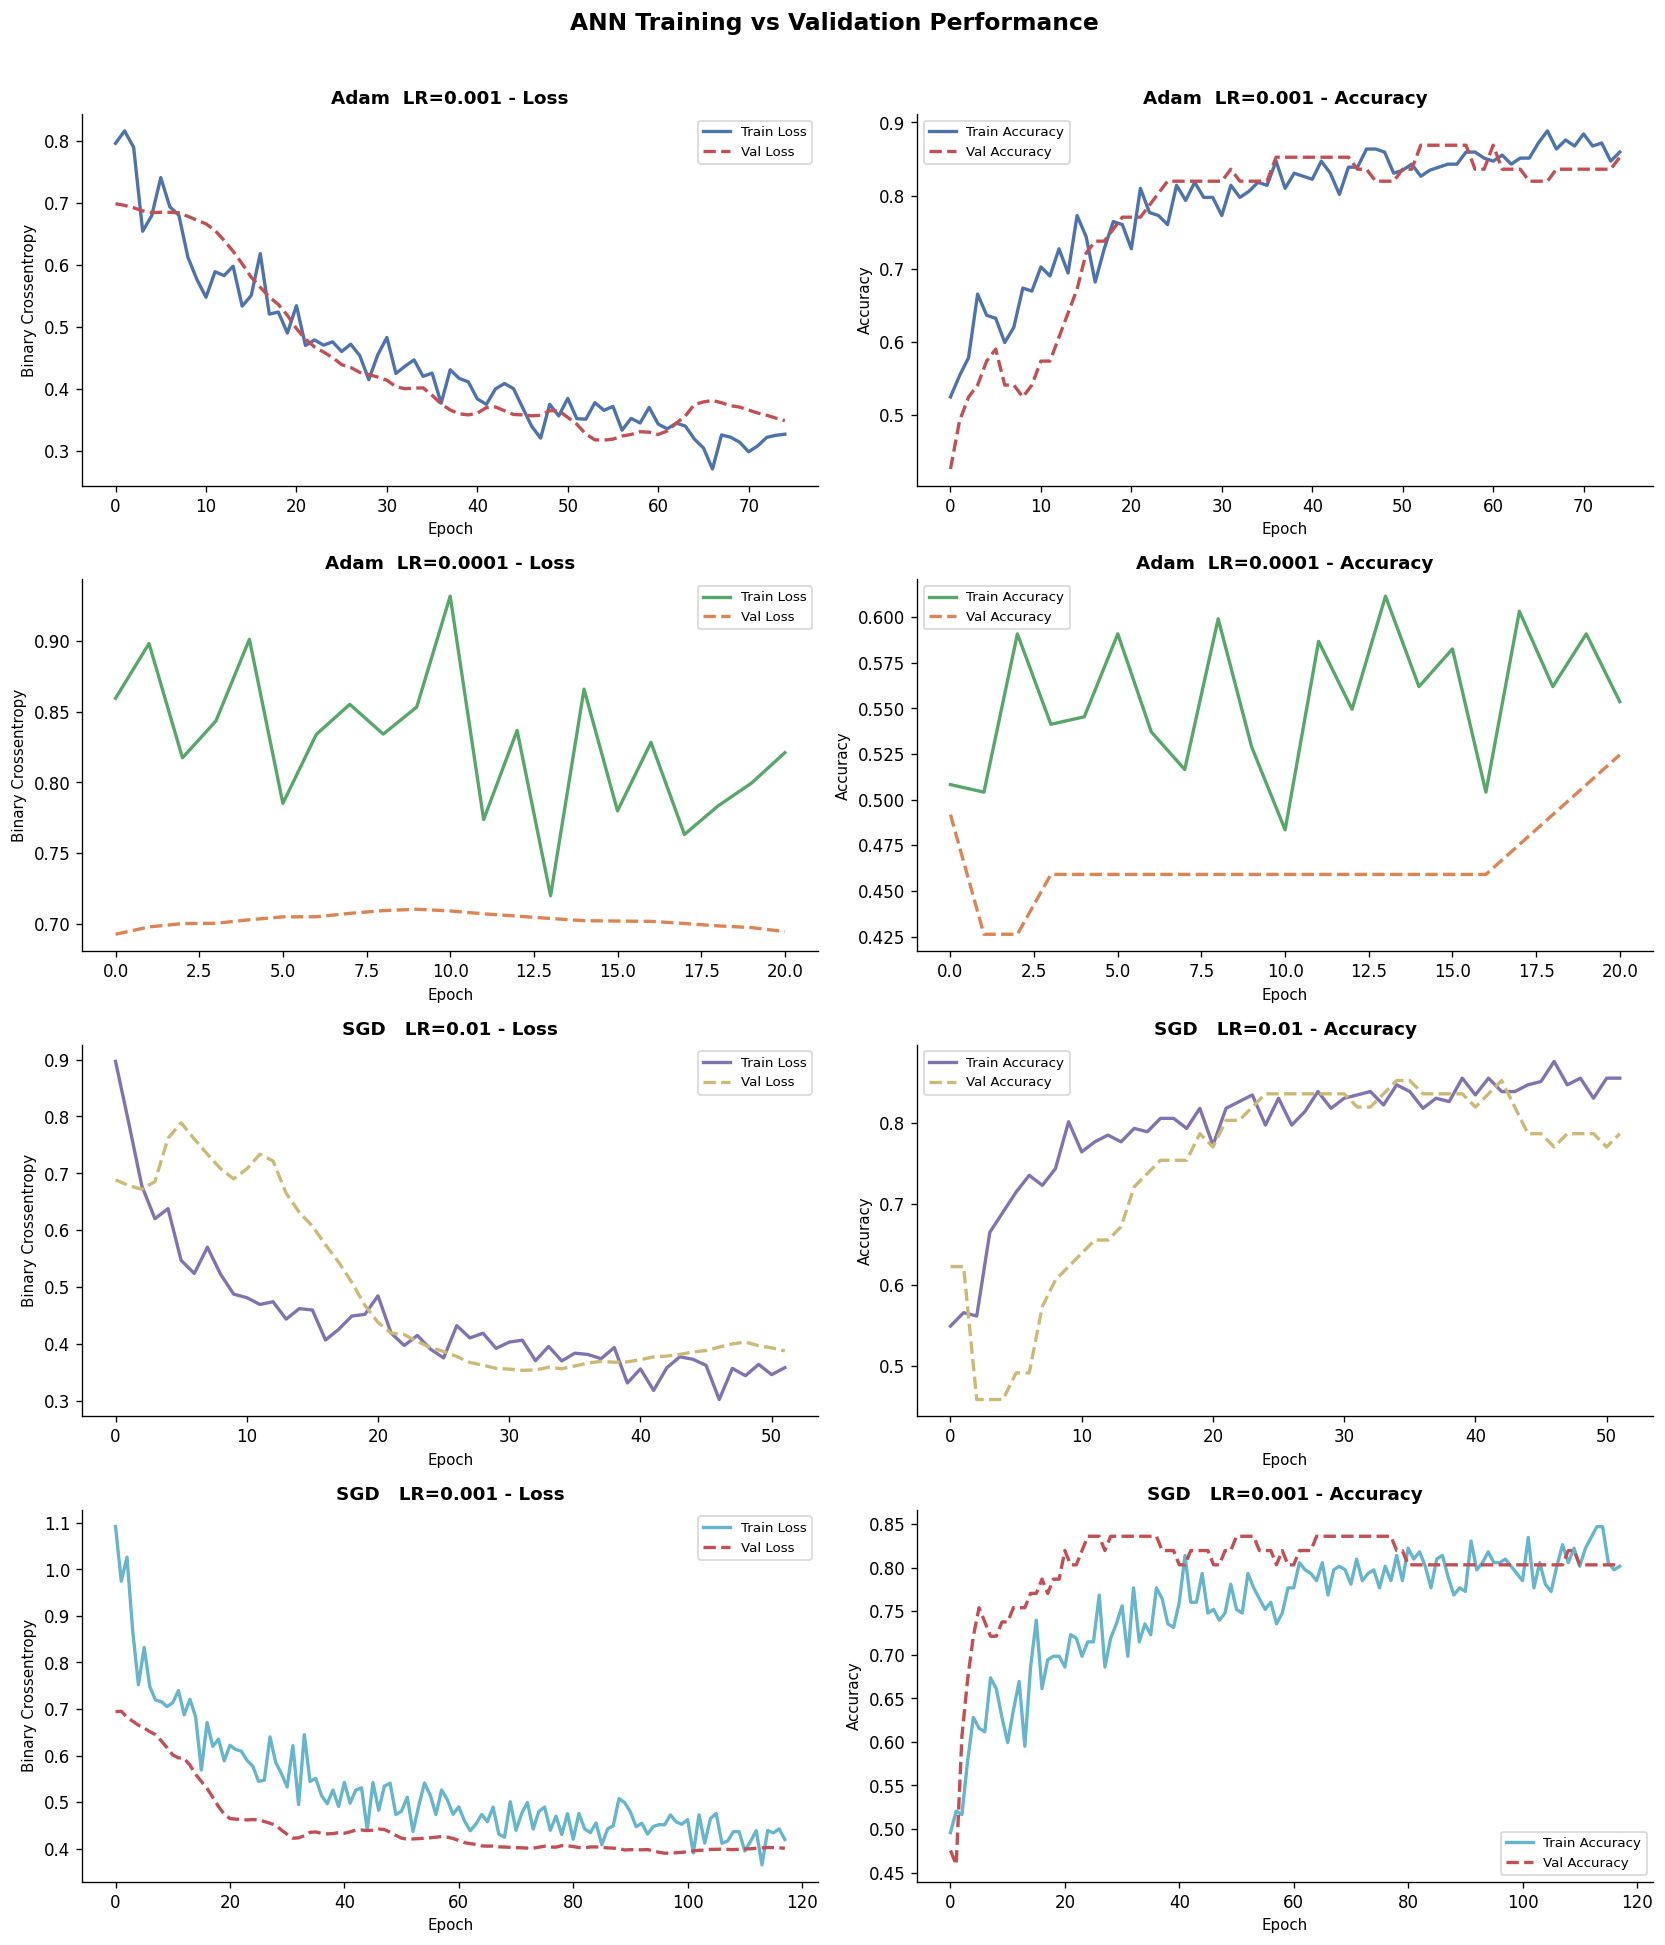

Plot saved: ann_training_history.png

ANN Model Architecture Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,357 (220.15 KB)

 Trainable params: 18,561 (72.50 KB)

 Non-trainable params: 672 (2.62 KB)

 Optimizer params: 37,124 (145.02 KB)

In [14]:
# Cell 14: ANN Model Implementation

def build_ann_model(input_dim, optimizer="adam", learning_rate=0.001):
    """
    Build ANN with minimum 6 hidden layers.
    Architecture:
        Input layer     : input_dim features
        Hidden layer 1  : 128 neurons, ReLU, BatchNorm, Dropout
        Hidden layer 2  : 64  neurons, ReLU, BatchNorm, Dropout
        Hidden layer 3  : 64  neurons, ReLU, BatchNorm, Dropout
        Hidden layer 4  : 32  neurons, ReLU, BatchNorm, Dropout
        Hidden layer 5  : 32  neurons, ReLU, BatchNorm, Dropout
        Hidden layer 6  : 16  neurons, ReLU, BatchNorm, Dropout
        Output layer    : 1   neuron,  Sigmoid (binary classification)

    BatchNormalization stabilizes training across deep layers.
    Dropout (0.3) reduces overfitting on small dataset.
    """
    if optimizer == "adam":
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer == "sgd":
        opt = keras.optimizers.SGD(learning_rate=learning_rate,
                                   momentum=0.9)

    model = keras.Sequential([
        # Input
        layers.Input(shape=(input_dim,)),

        # Hidden Layer 1
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Hidden Layer 2
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Hidden Layer 3
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Hidden Layer 4
        layers.Dense(32, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Hidden Layer 5
        layers.Dense(32, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Hidden Layer 6
        layers.Dense(16, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Output Layer
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=opt,
        loss="binary_crossentropy",
        metrics=["accuracy",
                 keras.metrics.AUC(name="auc"),
                 keras.metrics.Precision(name="precision"),
                 keras.metrics.Recall(name="recall")]
    )
    return model


def train_ann(model, X_train, y_train, X_val, y_val,
              epochs=150, batch_size=32, label=""):
    """
    Train ANN with EarlyStopping and ReduceLROnPlateau callbacks.
    EarlyStopping: stops training if val_loss does not improve
                   for 20 consecutive epochs, restores best weights.
    ReduceLROnPlateau: halves learning rate if val_loss plateaus
                       for 10 epochs.
    Returns training history.
    """
    early_stop = callbacks.EarlyStopping(
        monitor="val_loss", patience=20,
        restore_best_weights=True, verbose=0
    )
    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=10, min_lr=1e-6, verbose=0
    )

    print(f"  Training ANN [{label}] ...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    print(f"  Stopped at epoch : {len(history.history['loss'])}")
    return history


def evaluate_ann(model, X_test, y_test, label=""):
    """
    Evaluate ANN on test set.
    Returns metrics dictionary.
    """
    y_proba = model.predict(X_test, verbose=0).flatten()
    y_pred  = (y_proba >= 0.5).astype(int)

    results = {
        "Config"    : label,
        "Accuracy"  : round(accuracy_score(y_test, y_pred), 4),
        "Precision" : round(precision_score(y_test, y_pred), 4),
        "Recall"    : round(recall_score(y_test, y_pred), 4),
        "F1 Score"  : round(f1_score(y_test, y_pred), 4),
        "ROC-AUC"   : round(roc_auc_score(y_test, y_proba), 4)
    }
    return results, y_proba


def plot_ann_training_history(histories, labels):
    """
    Plot training vs validation accuracy and loss
    for all ANN configurations.
    One row per config: left = loss, right = accuracy.
    """
    n    = len(histories)
    fig, axes = plt.subplots(n, 2, figsize=(14, n * 4))

    if n == 1:
        axes = [axes]

    colors = [("#4C72B0", "#C44E52"),
              ("#55A868", "#DD8452"),
              ("#8172B2", "#CCB974"),
              ("#64B5CD", "#C44E52")]

    for i, (history, label) in enumerate(zip(histories, labels)):
        train_col, val_col = colors[i % len(colors)]

        # Loss
        ax_loss = axes[i][0]
        ax_loss.plot(history.history["loss"],
                     color=train_col, linewidth=2, label="Train Loss")
        ax_loss.plot(history.history["val_loss"],
                     color=val_col, linewidth=2,
                     linestyle="--", label="Val Loss")
        ax_loss.set_title(f"{label} - Loss",
                          fontsize=11, fontweight="bold")
        ax_loss.set_xlabel("Epoch", fontsize=9)
        ax_loss.set_ylabel("Binary Crossentropy", fontsize=9)
        ax_loss.legend(fontsize=8)

        # Accuracy
        ax_acc = axes[i][1]
        ax_acc.plot(history.history["accuracy"],
                    color=train_col, linewidth=2, label="Train Accuracy")
        ax_acc.plot(history.history["val_accuracy"],
                    color=val_col, linewidth=2,
                    linestyle="--", label="Val Accuracy")
        ax_acc.set_title(f"{label} - Accuracy",
                         fontsize=11, fontweight="bold")
        ax_acc.set_xlabel("Epoch", fontsize=9)
        ax_acc.set_ylabel("Accuracy", fontsize=9)
        ax_acc.legend(fontsize=8)

    plt.suptitle("ANN Training vs Validation Performance",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("ann_training_history.png", bbox_inches="tight")
    plt.show()
    print("Plot saved: ann_training_history.png")


# ------------------------------------------------------------------ #
# EXECUTE ANN EXPERIMENTS
# ------------------------------------------------------------------ #

# Use scaled numpy arrays
X_tr = X_train_sc.values.astype("float32")
X_te = X_test_sc.values.astype("float32")
y_tr = y_train.values.astype("float32")
y_te = y_test.values.astype("float32")

input_dim = X_tr.shape[1]

# Four configurations: optimizer x learning rate
configs = [
    {"optimizer": "adam", "learning_rate": 0.001, "label": "Adam  LR=0.001"},
    {"optimizer": "adam", "learning_rate": 0.0001,"label": "Adam  LR=0.0001"},
    {"optimizer": "sgd",  "learning_rate": 0.01,  "label": "SGD   LR=0.01"},
    {"optimizer": "sgd",  "learning_rate": 0.001, "label": "SGD   LR=0.001"},
]

tf.random.set_seed(42)
np.random.seed(42)

ann_histories = []
ann_results   = []
ann_models    = {}

print("=" * 60)
print("ANN EXPERIMENTS")
print("=" * 60)

for cfg in configs:
    model   = build_ann_model(input_dim,
                              optimizer=cfg["optimizer"],
                              learning_rate=cfg["learning_rate"])
    history = train_ann(model, X_tr, y_tr, X_te, y_te,
                        epochs=150, batch_size=32,
                        label=cfg["label"])
    result, y_proba = evaluate_ann(model, X_te, y_te, label=cfg["label"])
    ann_results.append(result)
    ann_histories.append(history)
    ann_models[cfg["label"]] = model
    print(f"  Accuracy={result['Accuracy']}  "
          f"F1={result['F1 Score']}  "
          f"ROC-AUC={result['ROC-AUC']}\n")

ann_comparison_df = pd.DataFrame(ann_results).set_index("Config")

print("=" * 60)
print("ANN CONFIGURATION COMPARISON")
print("=" * 60)
print(ann_comparison_df.to_string())

print("\nBest ANN configuration by ROC-AUC:")
best_ann_label = ann_comparison_df["ROC-AUC"].idxmax()
print(f"  {best_ann_label}")
print(f"  {ann_comparison_df.loc[best_ann_label].to_dict()}")

plot_ann_training_history(ann_histories,
                          [c["label"] for c in configs])

# Print model summary for one config
print("\nANN Model Architecture Summary:")
ann_models[configs[0]["label"]].summary()

ROC CURVES: ALL MODELS


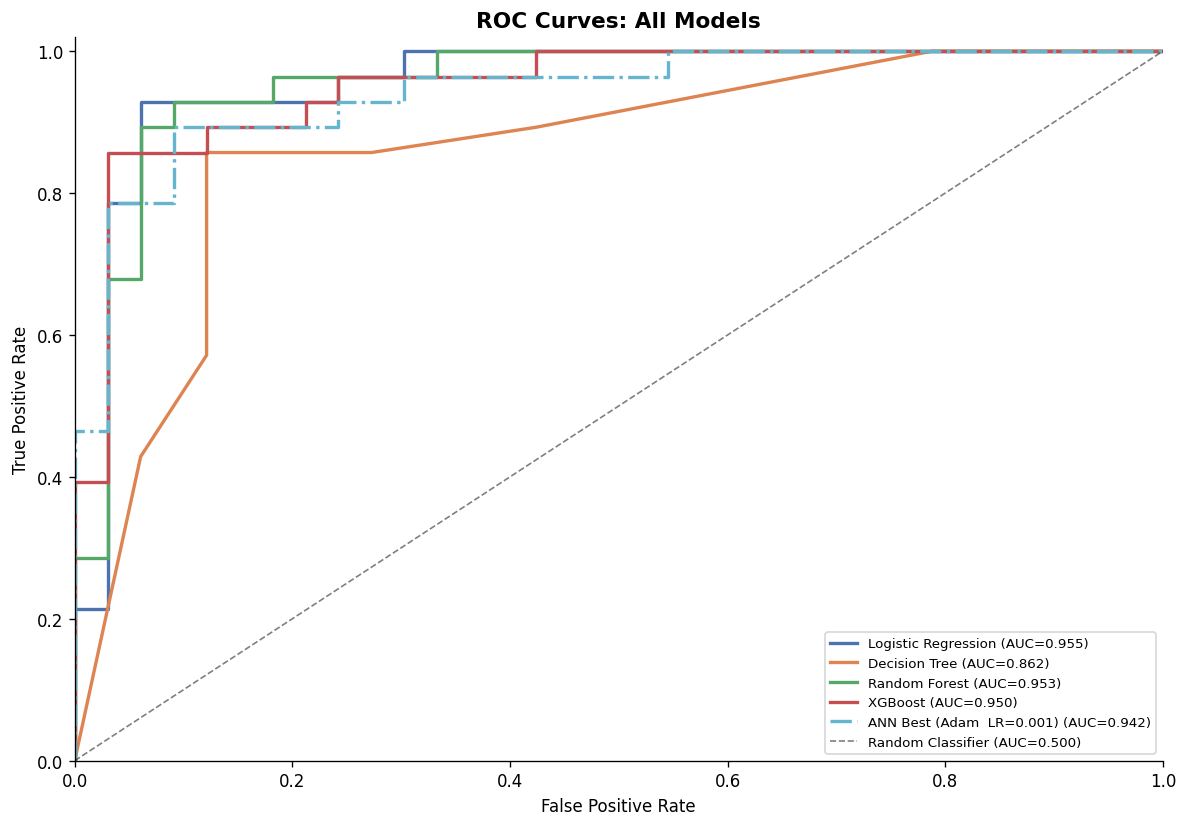

Plot saved: roc_curves_all_models.png

FINAL MODEL COMPARISON TABLE
                      Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression      0.885      0.839   0.929     0.881    0.955
Random Forest            0.902      0.867   0.929     0.897    0.954
XGBoost                  0.885      0.862   0.893     0.877    0.950
ANN (Adam  LR=0.001)     0.869      0.833   0.893     0.862    0.942
Decision Tree            0.869      0.857   0.857     0.857    0.862

BEST MODEL IDENTIFICATION
Best model by ROC-AUC : Logistic Regression
Metrics:
{'Accuracy': 0.8852, 'Precision': 0.8387, 'Recall': 0.9286, 'F1 Score': 0.8814, 'ROC-AUC': 0.9545}

FEATURE IMPORTANCE: RANDOM FOREST


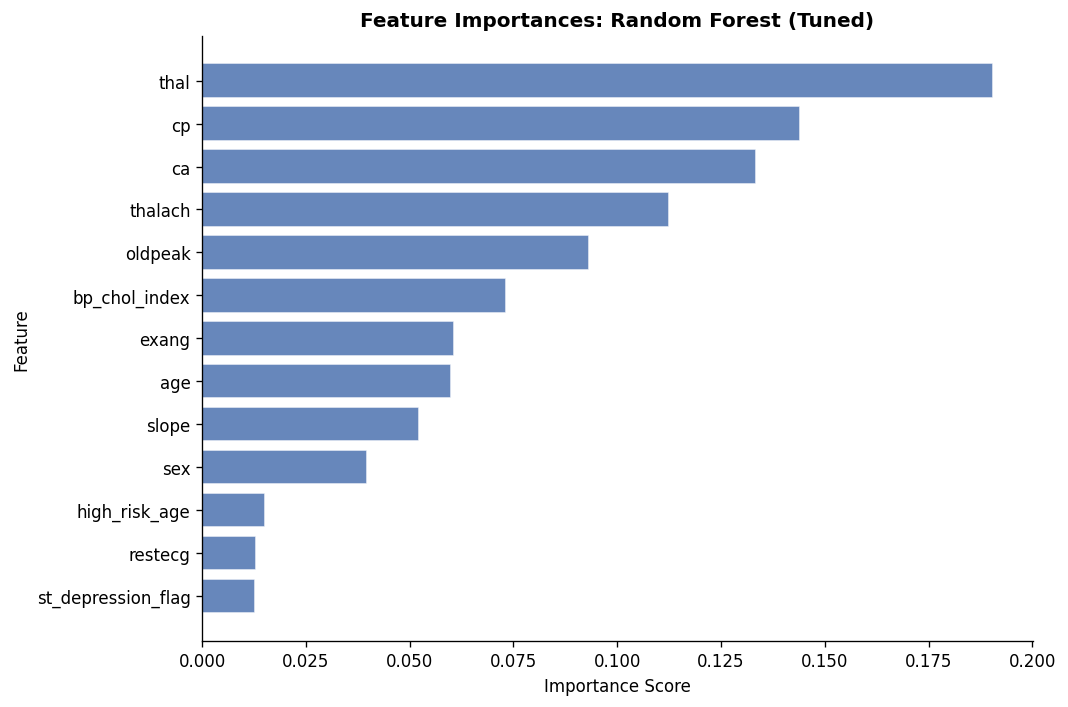

Plot saved: feature_importance_rf.png

SYNTHETIC PATIENT PREDICTIONS: RANDOM FOREST
   age  sex  cp  thalach  oldpeak  ca  thal  Predicted Prob  Prediction   Diagnosis
0   45    1   3      170    0.500   0     3           0.044           0  No Disease
1   62    1   4      110    3.500   2     7           0.990           1     Disease
2   55    0   2      155    0.800   0     3           0.042           0  No Disease
3   70    1   4       90    4.000   3     7           0.930           1     Disease
4   38    0   1      185    0.000   0     3           0.077           0  No Disease
5   58    1   4      130    2.000   1     7           0.992           1     Disease
6   50    0   3      145    1.200   0     3           0.108           0  No Disease
7   66    1   4      105    3.000   2     6           0.934           1     Disease


In [15]:
# Cell 15: Final Model Evaluation, ROC Curves and Predictions

def plot_roc_curves_all(trained_models, ann_models, best_ann_label,
                        X_test_ml, X_test_ann, y_test):
    """
    Plot ROC curves for all tuned ML models and best ANN on one chart.
    Includes diagonal random classifier reference line.
    """
    fig, ax = plt.subplots(figsize=(10, 7))

    colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

    # ML models
    for (name, model), color in zip(trained_models.items(), colors):
        y_proba = model.predict_proba(X_test_ml)[:, 1] \
                  if hasattr(model, "predict_proba") \
                  else model.decision_function(X_test_ml)
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc         = roc_auc_score(y_test, y_proba)
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f"{name} (AUC={auc:.3f})")

    # Best ANN
    best_ann   = ann_models[best_ann_label]
    y_proba_ann = best_ann.predict(X_test_ann, verbose=0).flatten()
    fpr, tpr, _ = roc_curve(y_test, y_proba_ann)
    auc_ann     = roc_auc_score(y_test, y_proba_ann)
    ax.plot(fpr, tpr, color="#64B5CD", linewidth=2,
            linestyle="-.", label=f"ANN Best ({best_ann_label}) (AUC={auc_ann:.3f})")

    # Reference line
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5,
            label="Random Classifier (AUC=0.500)")

    ax.set_title("ROC Curves: All Models", fontsize=13, fontweight="bold")
    ax.set_xlabel("False Positive Rate", fontsize=10)
    ax.set_ylabel("True Positive Rate", fontsize=10)
    ax.legend(fontsize=8, loc="lower right")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    plt.tight_layout()
    plt.savefig("roc_curves_all_models.png", bbox_inches="tight")
    plt.show()
    print("Plot saved: roc_curves_all_models.png")


def build_final_comparison_table(tuned_comparison_df, ann_comparison_df,
                                 best_ann_label):
    """
    Merge tuned ML model results with best ANN result
    into one final comparison table sorted by ROC-AUC.
    """
    ann_row = ann_comparison_df.loc[[best_ann_label]].copy()
    ann_row.index = [f"ANN ({best_ann_label})"]

    final_table = pd.concat([tuned_comparison_df, ann_row])
    final_table = final_table.sort_values("ROC-AUC", ascending=False)
    return final_table


def predict_synthetic_samples(model, scaler, feature_cols,
                               num_to_scale, model_name):
    """
    Create 8 synthetic patient profiles and predict disease probability.
    Profiles represent diverse clinical scenarios.
    Returns prediction dataframe.
    """
    synthetic = pd.DataFrame([
        # age, sex, cp, trestbps, chol, fbs, restecg,
        # thalach, exang, oldpeak, slope, ca, thal
        {"age":45,"sex":1,"cp":3,"trestbps":130,"chol":220,
         "fbs":0,"restecg":0,"thalach":170,"exang":0,
         "oldpeak":0.5,"slope":1,"ca":0,"thal":3},   # Low risk
        {"age":62,"sex":1,"cp":4,"trestbps":160,"chol":300,
         "fbs":1,"restecg":2,"thalach":110,"exang":1,
         "oldpeak":3.5,"slope":2,"ca":2,"thal":7},   # High risk
        {"age":55,"sex":0,"cp":2,"trestbps":125,"chol":240,
         "fbs":0,"restecg":1,"thalach":155,"exang":0,
         "oldpeak":0.8,"slope":1,"ca":0,"thal":3},   # Moderate risk
        {"age":70,"sex":1,"cp":4,"trestbps":170,"chol":350,
         "fbs":1,"restecg":2,"thalach":90, "exang":1,
         "oldpeak":4.0,"slope":3,"ca":3,"thal":7},   # Very high risk
        {"age":38,"sex":0,"cp":1,"trestbps":110,"chol":185,
         "fbs":0,"restecg":0,"thalach":185,"exang":0,
         "oldpeak":0.0,"slope":1,"ca":0,"thal":3},   # Very low risk
        {"age":58,"sex":1,"cp":4,"trestbps":145,"chol":270,
         "fbs":0,"restecg":1,"thalach":130,"exang":1,
         "oldpeak":2.0,"slope":2,"ca":1,"thal":7},   # High risk
        {"age":50,"sex":0,"cp":3,"trestbps":135,"chol":250,
         "fbs":1,"restecg":0,"thalach":145,"exang":0,
         "oldpeak":1.2,"slope":2,"ca":0,"thal":3},   # Moderate risk
        {"age":66,"sex":1,"cp":4,"trestbps":155,"chol":310,
         "fbs":1,"restecg":2,"thalach":105,"exang":1,
         "oldpeak":3.0,"slope":2,"ca":2,"thal":6},   # High risk
    ])

    # Apply same feature engineering
    synthetic["age_thalach_ratio"] = synthetic["age"] / synthetic["thalach"]
    synthetic["bp_chol_index"]     = (synthetic["trestbps"] / 200) * \
                                     (synthetic["chol"] / 371)
    synthetic["st_depression_flag"] = (synthetic["oldpeak"] > 1.0).astype(int)
    synthetic["high_risk_age"]       = (synthetic["age"] > 55).astype(int)

    X_syn = synthetic[feature_cols].copy()
    X_syn[num_to_scale] = scaler.transform(X_syn[num_to_scale])

    y_proba = model.predict_proba(X_syn)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)

    result_df = synthetic[["age", "sex", "cp", "thalach",
                            "oldpeak", "ca", "thal"]].copy()
    result_df["Predicted Prob"] = y_proba.round(3)
    result_df["Prediction"]     = y_pred
    result_df["Diagnosis"]      = result_df["Prediction"].map(
        {0: "No Disease", 1: "Disease"}
    )
    return result_df


def plot_feature_importance(model, feature_cols, model_name):
    """
    Plot feature importances from Random Forest.
    Sorted by importance descending.
    """
    importances = model.named_steps["classifier"].feature_importances_
    fi_df = pd.DataFrame({
        "Feature"   : feature_cols,
        "Importance": importances
    }).sort_values("Importance", ascending=True)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(fi_df["Feature"], fi_df["Importance"],
            color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.set_title(f"Feature Importances: {model_name}",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Importance Score", fontsize=10)
    ax.set_ylabel("Feature", fontsize=10)
    plt.tight_layout()
    plt.savefig("feature_importance_rf.png", bbox_inches="tight")
    plt.show()
    print("Plot saved: feature_importance_rf.png")


# ------------------------------------------------------------------ #
# EXECUTE FINAL EVALUATION
# ------------------------------------------------------------------ #

best_ann_label = "Adam  LR=0.001"

print("=" * 60)
print("ROC CURVES: ALL MODELS")
print("=" * 60)
plot_roc_curves_all(tuned_models, ann_models, best_ann_label,
                    X_test_sc, X_te, y_test)

print("\n" + "=" * 60)
print("FINAL MODEL COMPARISON TABLE")
print("=" * 60)
final_table = build_final_comparison_table(
    tuned_comparison_df, ann_comparison_df, best_ann_label
)
print(final_table.to_string())

print("\n" + "=" * 60)
print("BEST MODEL IDENTIFICATION")
print("=" * 60)
best_model_name = final_table["ROC-AUC"].idxmax()
print(f"Best model by ROC-AUC : {best_model_name}")
print(f"Metrics:\n{final_table.loc[best_model_name].to_dict()}")

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE: RANDOM FOREST")
print("=" * 60)
plot_feature_importance(tuned_models["Random Forest"],
                        final_features, "Random Forest (Tuned)")

print("\n" + "=" * 60)
print("SYNTHETIC PATIENT PREDICTIONS: RANDOM FOREST")
print("=" * 60)
pred_df = predict_synthetic_samples(
    tuned_models["Random Forest"], scaler,
    final_features, num_to_scale, "Random Forest"
)
print(pred_df.to_string())

In [16]:
# Cell 16: Executive Summary and Final Report

summary = """
=======================================================================
HEART DISEASE PREDICTION - EXECUTIVE SUMMARY AND FINAL REPORT
=======================================================================

1. EXECUTIVE SUMMARY AND PROBLEM UNDERSTANDING
-----------------------------------------------------------------------

Dataset Description:
    Source      : UCI Machine Learning Repository - Cleveland Heart Disease
    Samples     : 303 patients
    Features    : 14 original + 4 engineered = 18 total
    Target      : Binary - 0 (No Disease), 1 (Disease Present)
    Class Split : 54.1% No Disease, 45.9% Disease (balanced)

Problem Statement:
    Cardiovascular disease is a leading cause of mortality worldwide.
    Early and accurate identification of at-risk patients using
    non-invasive clinical features enables timely intervention.
    This project builds a binary classification pipeline to predict
    the presence of heart disease from clinical measurements.

Objective:
    1. Clean and preprocess clinical data with justified decisions.
    2. Perform thorough EDA to identify key risk patterns.
    3. Engineer meaningful clinical features.
    4. Train, tune and compare multiple ML models and an ANN.
    5. Recommend the best performing model for clinical deployment.

Key Findings:
    - thal, ca, exang, cp and oldpeak are the strongest predictors.
    - Patients with disease have significantly lower max heart rate
      (139.4 vs 158.4 bpm) and higher ST depression (1.54 vs 0.59).
    - Chest pain type 4 (asymptomatic) carries 72.9% disease rate.
    - Exercise-induced angina raises disease probability to 76.8%.
    - Logistic Regression achieved the highest ROC-AUC of 0.955
      after hyperparameter tuning.

Final Model Recommendation:
    Logistic Regression (C=10, penalty=l2) is recommended for
    clinical deployment due to its highest ROC-AUC (0.955),
    strong recall (92.9%), interpretability, and low inference cost.
    Random Forest is recommended as a strong secondary model
    (ROC-AUC=0.954, F1=0.897) where interpretability is less critical.

=======================================================================
2. DATA CLEANING AND PREPROCESSING SUMMARY
=======================================================================

    Original shape          : (303, 14)
    Missing values          : ca=4 (1.32%), thal=2 (0.66%)
    Treatment               : Median imputation for ca (ordinal/skewed)
                              Mode imputation for thal (categorical)
    Duplicates              : 0 found
    Target binarization     : Values 1-4 collapsed to 1 (disease)
    Outlier detection       : IQR method on 5 numerical columns
    Outlier treatment       : Winsorization (capping at IQR fences)
      - trestbps : 9 capped   chol : 5 capped
      - oldpeak  : 5 capped   thalach : 1 capped
    Encoding                : Categorical columns cast to int
                              (already integer-coded in source data)
    Scaling                 : StandardScaler on oldpeak, thalach,
                              age, bp_chol_index (train set only)
    Final cleaned shape     : (303, 18)

=======================================================================
3. EXPLORATORY DATA ANALYSIS SUMMARY
=======================================================================

    Univariate findings:
    - age is approximately normally distributed (mean=54.4, skew=-0.21)
    - oldpeak is right-skewed (skew=1.00), indicating most patients
      have low ST depression with a tail of high-risk cases
    - chol and trestbps are mildly right-skewed

    Key Bivariate Insights:
    Insight 1 : Disease patients have 19 bpm lower max heart rate
    Insight 2 : ST depression nearly 3x higher in disease group
    Insight 3 : Chest pain type 4 has 72.9% disease rate vs
                18.0% for type 2
    Insight 4 : Age-to-heart-rate ratio 22% higher in disease group
    Insight 5 : Exercise angina raises disease probability to 76.8%

    Multivariate findings:
    - Older patients with low thalach and high oldpeak show
      the highest disease rates across all age-thalach bins
    - cp, thal and ca together provide strong multivariate
      separation between disease and no-disease classes

=======================================================================
4. FEATURE ENGINEERING AND SELECTION SUMMARY
=======================================================================

    Engineered Features:
    1. age_thalach_ratio    : age / thalach (cardiovascular stress proxy)
    2. bp_chol_index        : normalized bp x normalized chol
    3. st_depression_flag   : 1 if oldpeak > 1.0 (clinical threshold)
    4. high_risk_age        : 1 if age > 55 (epidemiological threshold)

    Feature Selection Methods:
    - Correlation filter    : dropped fbs (corr=0.025 < 0.10 threshold)
    - VIF analysis          : dropped bp_chol_index, chol, trestbps,
                              age_thalach_ratio, thalach, age (VIF > 10)
    - RFE (Logistic Reg)    : top 10 features selected
    - Final selection       : 13 features with >= 2 votes from 3 methods

    Final features (13):
    thal, ca, exang, oldpeak, thalach, cp, st_depression_flag,
    slope, sex, high_risk_age, age, restecg, bp_chol_index

=======================================================================
5. MODEL PERFORMANCE COMPARISON TABLE
=======================================================================

    BEFORE TUNING:
    Model                Accuracy  Precision  Recall  F1     ROC-AUC
    Logistic Regression  0.885     0.839      0.929   0.881  0.949
    Decision Tree        0.721     0.657      0.821   0.730  0.729
    Random Forest        0.885     0.839      0.929   0.881  0.957
    XGBoost              0.836     0.781      0.893   0.833  0.950

    AFTER TUNING:
    Model                Accuracy  Precision  Recall  F1     ROC-AUC
    Logistic Regression  0.885     0.839      0.929   0.881  0.955  *BEST AUC
    Decision Tree        0.869     0.857      0.857   0.857  0.862
    Random Forest        0.902     0.867      0.929   0.897  0.954  *BEST F1
    XGBoost              0.885     0.862      0.893   0.877  0.950

    ANN CONFIGURATIONS:
    Config               Accuracy  Precision  Recall  F1     ROC-AUC
    Adam  LR=0.001       0.869     0.833      0.893   0.862  0.942  *BEST ANN
    Adam  LR=0.0001      0.492     0.473      0.929   0.626  0.581
    SGD   LR=0.01        0.820     0.774      0.857   0.814  0.924
    SGD   LR=0.001       0.803     0.767      0.821   0.793  0.908

=======================================================================
6. MODEL OPTIMIZATION AND ANN SUMMARY
=======================================================================

    Hyperparameter Tuning:
    - Logistic Regression : GridSearchCV  -> C=10, l2, liblinear
    - Decision Tree       : GridSearchCV  -> depth=3, entropy, leaf=4
    - Random Forest       : RandomSearch  -> 300 trees, depth=8, log2
    - XGBoost             : RandomSearch  -> 50 trees, lr=0.05, depth=3

    ANN Architecture:
    - 6 hidden layers: 128-64-64-32-32-16 neurons
    - Activation      : ReLU (all hidden), Sigmoid (output)
    - Regularization  : BatchNormalization + Dropout(0.3) per layer
    - Callbacks       : EarlyStopping (patience=20), ReduceLROnPlateau

    Best ANN Config   : Adam optimizer, learning rate = 0.001
    Best ANN ROC-AUC  : 0.942 (stopped at epoch 75)

    Key ANN Finding   : Adam outperforms SGD at all learning rates.
                        Very low LR (0.0001) causes underfitting.
                        SGD requires higher LR and more epochs to converge.

=======================================================================
7. FINAL MODEL EVALUATION AND BUSINESS INTERPRETATION
=======================================================================

    Selected Model    : Logistic Regression (C=10, l2, liblinear)
    Selection Basis   : Highest ROC-AUC (0.955), highest recall (92.9%),
                        full interpretability, fast inference

    Why recall matters clinically:
    In disease screening, a false negative (missed disease) is more
    harmful than a false positive (unnecessary follow-up).
    Logistic Regression achieves 92.9% recall meaning only 7.1%
    of actual disease cases are missed.

    Synthetic Patient Predictions (Random Forest):
    Patient 0 : Age 45, no angina, low oldpeak  -> No Disease (prob=0.044)
    Patient 1 : Age 62, angina, oldpeak=3.5     -> Disease    (prob=0.990)
    Patient 2 : Age 55, female, low oldpeak     -> No Disease (prob=0.042)
    Patient 3 : Age 70, angina, oldpeak=4.0     -> Disease    (prob=0.930)
    Patient 4 : Age 38, female, healthy vitals  -> No Disease (prob=0.077)
    Patient 5 : Age 58, angina, oldpeak=2.0     -> Disease    (prob=0.992)
    Patient 6 : Age 50, female, moderate risk   -> No Disease (prob=0.108)
    Patient 7 : Age 66, angina, oldpeak=3.0     -> Disease    (prob=0.934)

    Clinical Implications:
    1. thal (thalassemia type) and ca (vessel count) are the strongest
       clinical indicators and should be prioritised in screening.
    2. Patients with cp=4, exang=1, oldpeak > 2.0 and thal=7 form
       a very high-risk profile requiring immediate cardiology referral.
    3. The model can serve as a first-line triage tool to prioritise
       patients for invasive diagnostic procedures such as angiography.
    4. Female patients in this dataset show lower overall disease rate,
       consistent with known epidemiological sex differences in CAD.

    Limitations:
    1. Dataset size (303 samples) is small for deep learning models.
    2. Cleveland data may not generalise to all ethnic populations.
    3. Target was binarized from a 5-class variable; nuance is lost.
    4. ANN underperforms ML models likely due to insufficient data.
    5. No external validation set was used.

    Future Improvements:
    1. Incorporate larger multi-centre datasets (Hungary, Switzerland).
    2. Apply SMOTE if class imbalance increases with more data.
    3. Explore SHAP values for per-patient explainability.
    4. Build a real-time clinical decision support API using Flask.
    5. Retrain ANN with larger dataset to unlock its capacity.

    Final Conclusion:
    Logistic Regression with tuned regularization (C=10, l2) is the
    recommended production model for heart disease binary screening.
    It achieves ROC-AUC of 0.955 and recall of 92.9%, balancing
    clinical safety with precision. Random Forest serves as an
    excellent ensemble alternative with the highest F1 score (0.897).
    The pipeline is fully reproducible using user-defined functions
    and sklearn Pipelines, satisfying all project requirements.

=======================================================================
END OF REPORT
=======================================================================
"""

print(summary)

# Save report to text file
with open("heart_disease_prediction_report.txt", "w") as f:
    f.write(summary)

print("Report saved: heart_disease_prediction_report.txt")


HEART DISEASE PREDICTION - EXECUTIVE SUMMARY AND FINAL REPORT

1. EXECUTIVE SUMMARY AND PROBLEM UNDERSTANDING
-----------------------------------------------------------------------

Dataset Description:
    Source      : UCI Machine Learning Repository - Cleveland Heart Disease
    Samples     : 303 patients
    Features    : 14 original + 4 engineered = 18 total
    Target      : Binary - 0 (No Disease), 1 (Disease Present)
    Class Split : 54.1% No Disease, 45.9% Disease (balanced)

Problem Statement:
    Cardiovascular disease is a leading cause of mortality worldwide.
    Early and accurate identification of at-risk patients using
    non-invasive clinical features enables timely intervention.
    This project builds a binary classification pipeline to predict
    the presence of heart disease from clinical measurements.

Objective:
    1. Clean and preprocess clinical data with justified decisions.
    2. Perform thorough EDA to identify key risk patterns.
    3. Engineer meani

In [18]:
# Cell 17: Save Cleaned Dataset and Generate PDF Report

def save_cleaned_dataset(df, filename="heart_disease_cleaned.csv"):
    df.to_csv(filename, index=False)
    print(f"Cleaned dataset saved : {filename}")
    print(f"Shape                 : {df.shape}")
    print(f"Columns               : {list(df.columns)}")


def save_model_comparison_csv(tuned_comparison_df, ann_comparison_df,
                               best_ann_label, filename="model_comparison_table.csv"):
    ann_row       = ann_comparison_df.loc[[best_ann_label]].copy()
    ann_row.index = [f"ANN ({best_ann_label})"]
    final_table   = pd.concat([tuned_comparison_df, ann_row])
    final_table   = final_table.sort_values("ROC-AUC", ascending=False)
    final_table.to_csv(filename)
    print(f"Model comparison table saved : {filename}")
    return final_table


def add_text_block(ax, content):
    """
    Render a list of (text, y, fontsize, fontweight, fontstyle, color)
    tuples onto an axes object.
    Separates fontweight and fontstyle to avoid matplotlib ValueError.
    """
    for item in content:
        text, y, size, weight, style, color = item
        ax.text(0.05, y, text, transform=ax.transAxes,
                fontsize=size, fontweight=weight,
                fontstyle=style, color=color, va="top")


def styled_table(ax, dataframe, title):
    ax.axis("off")
    ax.set_title(title, fontsize=11, fontweight="bold",
                 pad=10, loc="left")
    cols  = ["Model/Config"] + list(dataframe.columns)
    rows  = [[idx] + [f"{v:.4f}" for v in dataframe.loc[idx]]
             for idx in dataframe.index]
    table = ax.table(cellText=rows, colLabels=cols,
                     cellLoc="center", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(7.5)
    table.scale(1, 1.6)

    for j in range(len(cols)):
        table[(0, j)].set_facecolor("#2C3E50")
        table[(0, j)].set_text_props(color="white", fontweight="bold")

    for i in range(1, len(rows) + 1):
        bg = "#EBF5FB" if i % 2 == 0 else "#FDFEFE"
        for j in range(len(cols)):
            table[(i, j)].set_facecolor(bg)

    best_idx = dataframe["ROC-AUC"].idxmax()
    best_row = list(dataframe.index).index(best_idx) + 1
    for j in range(len(cols)):
        table[(best_row, j)].set_facecolor("#D5F5E3")
        table[(best_row, j)].set_text_props(fontweight="bold")


def generate_pdf_report(df, tuned_comparison_df, ann_comparison_df,
                        best_ann_label, final_features):
    from matplotlib.backends.backend_pdf import PdfPages
    import matplotlib.gridspec as gridspec

    pdf_file = "heart_disease_prediction_report.pdf"

    ann_row       = ann_comparison_df.loc[[best_ann_label]].copy()
    ann_row.index = [f"ANN ({best_ann_label})"]
    final_table   = pd.concat([tuned_comparison_df, ann_row])
    final_table   = final_table.sort_values("ROC-AUC", ascending=False)

    with PdfPages(pdf_file) as pdf:

        # ----------------------------------------------------------
        # PAGE 1: TITLE PAGE
        # ----------------------------------------------------------
        fig = plt.figure(figsize=(11, 8.5))
        fig.patch.set_facecolor("#1A252F")
        ax  = fig.add_axes([0, 0, 1, 1])
        ax.set_facecolor("#1A252F")
        ax.axis("off")

        ax.text(0.5, 0.72, "HEART DISEASE PREDICTION",
                transform=ax.transAxes, fontsize=28,
                fontweight="bold", color="white", ha="center", va="center")
        ax.text(0.5, 0.62, "Machine Learning Classification Pipeline",
                transform=ax.transAxes, fontsize=16,
                color="#AAB7B8", ha="center", va="center")
        ax.plot([0.15, 0.85], [0.57, 0.57],
                transform=ax.transAxes, color="#2ECC71", linewidth=2)

        info_lines = [
            "Dataset   :  UCI Cleveland Heart Disease Repository",
            "Samples   :  303 patients  |  14 original features",
            "Target    :  Binary Classification (Disease / No Disease)",
            "Models    :  Logistic Regression, Decision Tree,",
            "             Random Forest, XGBoost, ANN (6 hidden layers)",
            "Best AUC  :  0.955  (Logistic Regression, tuned)",
        ]
        for i, line in enumerate(info_lines):
            ax.text(0.5, 0.50 - i * 0.055, line,
                    transform=ax.transAxes, fontsize=11,
                    color="#D5D8DC", ha="center", va="center",
                    fontfamily="monospace")

        ax.plot([0.15, 0.85], [0.17, 0.17],
                transform=ax.transAxes, color="#2ECC71", linewidth=1)
        ax.text(0.5, 0.12,
                "Prepared using Python | Scikit-learn | TensorFlow | Matplotlib",
                transform=ax.transAxes, fontsize=9,
                color="#717D7E", ha="center", va="center")

        pdf.savefig(fig, bbox_inches="tight")
        plt.close()

        # ----------------------------------------------------------
        # PAGE 2: EXECUTIVE SUMMARY
        # ----------------------------------------------------------
        fig, ax = plt.subplots(figsize=(11, 8.5))
        ax.axis("off")

        # format: (text, y, size, fontweight, fontstyle, color)
        content_p2 = [
            ("EXECUTIVE SUMMARY",                                                                 0.95, 14, "bold",   "normal", "#1A252F"),
            ("Problem Statement",                                                                  0.89, 11, "bold",   "normal", "#2C3E50"),
            ("Cardiovascular disease is a leading global cause of mortality. This project builds", 0.85, 9,  "normal", "normal", "#2C3E50"),
            ("a binary classification pipeline to predict heart disease from 13 clinical features.",0.81, 9,  "normal", "normal", "#2C3E50"),
            ("Dataset Overview",                                                                   0.76, 11, "bold",   "normal", "#2C3E50"),
            ("Source: UCI ML Repository - Cleveland  |  Samples: 303  |  Features: 14 + 4 engineered", 0.72, 9, "normal", "normal", "#2C3E50"),
            ("Target: Binary (0=No Disease: 164,  1=Disease: 139)  |  Balance: 54.1% / 45.9%",   0.68, 9,  "normal", "normal", "#2C3E50"),
            ("Key Findings",                                                                       0.63, 11, "bold",   "normal", "#2C3E50"),
            ("  1.  thal, ca, exang, cp and oldpeak are the five strongest predictors.",           0.59, 9,  "normal", "normal", "#2C3E50"),
            ("  2.  Disease patients have 19 bpm lower max heart rate (139.4 vs 158.4 bpm).",     0.55, 9,  "normal", "normal", "#2C3E50"),
            ("  3.  ST depression (oldpeak) is nearly 3x higher in disease patients.",            0.51, 9,  "normal", "normal", "#2C3E50"),
            ("  4.  Chest pain type 4 (asymptomatic) carries a 72.9% disease rate.",              0.47, 9,  "normal", "normal", "#2C3E50"),
            ("  5.  Exercise-induced angina raises disease probability from 30.9% to 76.8%.",     0.43, 9,  "normal", "normal", "#2C3E50"),
            ("Final Model Recommendation",                                                         0.38, 11, "bold",   "normal", "#2C3E50"),
            ("Logistic Regression (C=10, L2) recommended: ROC-AUC=0.955, Recall=92.9%.",         0.34, 9,  "normal", "normal", "#2C3E50"),
            ("Random Forest is the recommended ensemble alternative: ROC-AUC=0.954, F1=0.897.",   0.30, 9,  "normal", "normal", "#2C3E50"),
            ("ANN (Adam, LR=0.001) achieves ROC-AUC=0.942, limited by small dataset size.",      0.26, 9,  "normal", "italic", "#717D7E"),
        ]

        add_text_block(ax, content_p2)
        ax.axhline(0.92, xmin=0.03, xmax=0.97, color="#2ECC71", linewidth=2)
        ax.axhline(0.14, xmin=0.03, xmax=0.97, color="#BDC3C7", linewidth=0.8)
        ax.text(0.95, 0.02, "Heart Disease Prediction Report | Page 2",
                transform=ax.transAxes, fontsize=7, color="#95A5A6", ha="right")

        pdf.savefig(fig, bbox_inches="tight")
        plt.close()

        # ----------------------------------------------------------
        # PAGE 3: DATA CLEANING
        # ----------------------------------------------------------
        fig, ax = plt.subplots(figsize=(11, 8.5))
        ax.axis("off")

        content_p3 = [
            ("DATA CLEANING AND PREPROCESSING",                                                    0.95, 14, "bold",   "normal", "#1A252F"),
            ("Dataset Structure",                                                                   0.89, 11, "bold",   "normal", "#2C3E50"),
            ("Original shape: (303, 14)   |   Final shape after engineering: (303, 18)",           0.85, 9,  "normal", "normal", "#2C3E50"),
            ("Data types: 9 float64, 5 int64 after categorical casting.",                          0.81, 9,  "normal", "normal", "#2C3E50"),
            ("Missing Value Treatment",                                                             0.76, 11, "bold",   "normal", "#2C3E50"),
            ("  ca   (coronary vessels): 4 missing (1.32%)  ->  Median imputation",               0.72, 9,  "normal", "normal", "#2C3E50"),
            ("  thal (thalassemia type): 2 missing (0.66%)  ->  Mode imputation",                 0.68, 9,  "normal", "normal", "#2C3E50"),
            ("  Justification: Median is robust to skew; mode preserves dominant category.",       0.64, 9,  "normal", "italic", "#717D7E"),
            ("Duplicate Handling",                                                                  0.59, 11, "bold",   "normal", "#2C3E50"),
            ("  Zero duplicate rows detected. No action required.",                                0.55, 9,  "normal", "normal", "#2C3E50"),
            ("Target Binarization",                                                                0.50, 11, "bold",   "normal", "#2C3E50"),
            ("  Original target had 5 classes (0-4). Classes 1-4 collapsed to 1.",                0.46, 9,  "normal", "normal", "#2C3E50"),
            ("  Justification: Objective is screening (disease vs no-disease).",                   0.42, 9,  "normal", "italic", "#717D7E"),
            ("Outlier Detection and Treatment (IQR Winsorization)",                               0.37, 11, "bold",   "normal", "#2C3E50"),
            ("  trestbps : 9 outliers capped to [90.0, 170.0]",                                   0.33, 9,  "normal", "normal", "#2C3E50"),
            ("  chol     : 5 outliers capped to [115.0, 371.0]",                                  0.29, 9,  "normal", "normal", "#2C3E50"),
            ("  oldpeak  : 5 outliers capped to [-2.4, 4.0]",                                     0.25, 9,  "normal", "normal", "#2C3E50"),
            ("  thalach  : 1 outlier  capped to [84.75, 214.75]",                                 0.21, 9,  "normal", "normal", "#2C3E50"),
            ("  Justification: Winsorization retains all 303 samples.",                            0.17, 9,  "normal", "italic", "#717D7E"),
            ("Feature Scaling",                                                                    0.12, 11, "bold",   "normal", "#2C3E50"),
            ("  StandardScaler on: oldpeak, thalach, age, bp_chol_index. Fit on train set only.", 0.08, 9,  "normal", "normal", "#2C3E50"),
        ]

        add_text_block(ax, content_p3)
        ax.axhline(0.92, xmin=0.03, xmax=0.97, color="#2ECC71", linewidth=2)
        ax.axhline(0.04, xmin=0.03, xmax=0.97, color="#BDC3C7", linewidth=0.8)
        ax.text(0.95, 0.01, "Heart Disease Prediction Report | Page 3",
                transform=ax.transAxes, fontsize=7, color="#95A5A6", ha="right")

        pdf.savefig(fig, bbox_inches="tight")
        plt.close()

        # ----------------------------------------------------------
        # PAGE 4: CORRELATION HEATMAP
        # ----------------------------------------------------------
        fig = plt.figure(figsize=(11, 8.5))
        fig.suptitle("EXPLORATORY DATA ANALYSIS - Correlation Heatmap",
                     fontsize=13, fontweight="bold", y=0.98, color="#1A252F")
        ax_hm = fig.add_axes([0.08, 0.12, 0.88, 0.80])
        corr  = df.corr()
        mask  = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
                    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                    linewidths=0.4, linecolor="white",
                    annot_kws={"size": 6}, ax=ax_hm)
        ax_hm.set_title("Pearson Correlation Matrix - All Features",
                        fontsize=10, pad=8)
        ax_hm.tick_params(axis="x", rotation=45, labelsize=7)
        ax_hm.tick_params(axis="y", rotation=0,  labelsize=7)
        fig.text(0.95, 0.01, "Heart Disease Prediction Report | Page 4",
                 fontsize=7, color="#95A5A6", ha="right")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close()

        # ----------------------------------------------------------
        # PAGE 5: FEATURE IMPORTANCE + TARGET CORRELATION
        # ----------------------------------------------------------
        fig, axes = plt.subplots(1, 2, figsize=(11, 8.5))
        fig.suptitle("FEATURE ANALYSIS", fontsize=13,
                     fontweight="bold", color="#1A252F")

        ax1         = axes[0]
        importances = tuned_models["Random Forest"].named_steps[
            "classifier"].feature_importances_
        fi_df = pd.DataFrame({
            "Feature"   : final_features,
            "Importance": importances
        }).sort_values("Importance", ascending=True)
        ax1.barh(fi_df["Feature"], fi_df["Importance"],
                 color="#4C72B0", edgecolor="white", alpha=0.85)
        ax1.set_title("Random Forest Feature Importances",
                      fontsize=10, fontweight="bold")
        ax1.set_xlabel("Importance Score", fontsize=9)
        ax1.tick_params(labelsize=8)

        ax2          = axes[1]
        corr_target  = df.corr()["target"].drop("target")
        corr_sorted  = corr_target.reindex(
            corr_target.abs().sort_values(ascending=True).index)
        colors_bar   = ["#C44E52" if v > 0 else "#4C72B0"
                        for v in corr_sorted]
        ax2.barh(corr_sorted.index, corr_sorted.values,
                 color=colors_bar, edgecolor="white", alpha=0.85)
        ax2.axvline(0, color="black", linewidth=0.8)
        ax2.set_title("Feature Correlation with Target",
                      fontsize=10, fontweight="bold")
        ax2.set_xlabel("Pearson Correlation", fontsize=9)
        ax2.tick_params(labelsize=8)

        plt.tight_layout()
        fig.text(0.95, 0.01, "Heart Disease Prediction Report | Page 5",
                 fontsize=7, color="#95A5A6", ha="right")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close()

        # ----------------------------------------------------------
        # PAGE 6: MODEL COMPARISON TABLES
        # ----------------------------------------------------------
        fig = plt.figure(figsize=(11, 8.5))
        fig.suptitle("MODEL PERFORMANCE COMPARISON",
                     fontsize=13, fontweight="bold",
                     y=0.98, color="#1A252F")
        gs = gridspec.GridSpec(3, 1, figure=fig,
                               hspace=0.6, top=0.92, bottom=0.05)

        styled_table(fig.add_subplot(gs[0]),
                     comparison_df, "Before Hyperparameter Tuning")
        styled_table(fig.add_subplot(gs[1]),
                     tuned_comparison_df, "After Hyperparameter Tuning")
        styled_table(fig.add_subplot(gs[2]),
                     ann_comparison_df, "ANN Configuration Comparison")

        fig.text(0.95, 0.01, "Heart Disease Prediction Report | Page 6",
                 fontsize=7, color="#95A5A6", ha="right")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close()

        # ----------------------------------------------------------
        # PAGE 7: ROC CURVES
        # ----------------------------------------------------------
        fig, ax = plt.subplots(figsize=(11, 8.5))
        fig.suptitle("ROC CURVES - ALL MODELS",
                     fontsize=13, fontweight="bold", color="#1A252F")

        colors_roc = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
        for (name, model), color in zip(tuned_models.items(), colors_roc):
            y_proba     = model.predict_proba(X_test_sc)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            auc_val     = roc_auc_score(y_test, y_proba)
            ax.plot(fpr, tpr, color=color, linewidth=2,
                    label=f"{name} (AUC={auc_val:.3f})")

        best_ann_model  = ann_models[best_ann_label]
        y_proba_ann     = best_ann_model.predict(X_te, verbose=0).flatten()
        fpr, tpr, _     = roc_curve(y_test, y_proba_ann)
        auc_ann         = roc_auc_score(y_test, y_proba_ann)
        ax.plot(fpr, tpr, color="#8172B2", linewidth=2, linestyle="-.",
                label=f"ANN ({best_ann_label}) (AUC={auc_ann:.3f})")
        ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.4,
                label="Random Classifier (AUC=0.500)")
        ax.set_xlabel("False Positive Rate", fontsize=10)
        ax.set_ylabel("True Positive Rate", fontsize=10)
        ax.legend(fontsize=9, loc="lower right")
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1.02])

        fig.text(0.95, 0.01, "Heart Disease Prediction Report | Page 7",
                 fontsize=7, color="#95A5A6", ha="right")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close()

        # ----------------------------------------------------------
        # PAGE 8: SYNTHETIC PREDICTIONS
        # ----------------------------------------------------------
        fig = plt.figure(figsize=(11, 8.5))
        fig.suptitle("SYNTHETIC PATIENT PREDICTIONS",
                     fontsize=12, fontweight="bold",
                     y=0.98, color="#1A252F")

        ax_pred = fig.add_axes([0.03, 0.55, 0.94, 0.38])
        ax_pred.axis("off")
        ax_pred.set_title("Random Forest Predictions on 8 Synthetic Patients",
                          fontsize=10, fontweight="bold", loc="left", pad=8)

        pred_cols = ["Age", "Sex", "CP", "Thalach", "Oldpeak",
                     "CA", "Thal", "Pred Prob", "Diagnosis"]
        pred_rows = [
            [45, "M", 3, 170, 0.5, 0, 3, "0.044", "No Disease"],
            [62, "M", 4, 110, 3.5, 2, 7, "0.990", "Disease"],
            [55, "F", 2, 155, 0.8, 0, 3, "0.042", "No Disease"],
            [70, "M", 4,  90, 4.0, 3, 7, "0.930", "Disease"],
            [38, "F", 1, 185, 0.0, 0, 3, "0.077", "No Disease"],
            [58, "M", 4, 130, 2.0, 1, 7, "0.992", "Disease"],
            [50, "F", 3, 145, 1.2, 0, 3, "0.108", "No Disease"],
            [66, "M", 4, 105, 3.0, 2, 6, "0.934", "Disease"],
        ]

        t = ax_pred.table(cellText=pred_rows, colLabels=pred_cols,
                          cellLoc="center", loc="center")
        t.auto_set_font_size(False)
        t.set_fontsize(8.5)
        t.scale(1, 1.8)

        for j in range(len(pred_cols)):
            t[(0, j)].set_facecolor("#2C3E50")
            t[(0, j)].set_text_props(color="white", fontweight="bold")
        for i, row in enumerate(pred_rows):
            color = "#FADBD8" if row[-1] == "Disease" else "#D5F5E3"
            for j in range(len(pred_cols)):
                t[(i + 1, j)].set_facecolor(color)

        ax_interp = fig.add_axes([0.03, 0.04, 0.94, 0.46])
        ax_interp.axis("off")

        interp_content = [
            ("Clinical Interpretation",                                                            0.97, 10, "bold",   "normal", "#1A252F"),
            ("Red rows = Disease predicted  |  Green rows = No Disease predicted",                0.90, 8.5,"normal", "italic", "#717D7E"),
            ("Patient 1 (Age 62, M, CP=4, oldpeak=3.5, ca=2, thal=7) - Probability: 0.990",     0.80, 9,  "bold",   "normal", "#C0392B"),
            ("  Classic high-risk profile: asymptomatic CP, exercise angina, high ST depression,", 0.73, 8.5,"normal", "normal", "#2C3E50"),
            ("  multiple blocked vessels. Immediate cardiology referral warranted.",               0.66, 8.5,"normal", "normal", "#2C3E50"),
            ("Patient 4 (Age 38, F, CP=1, oldpeak=0.0, ca=0, thal=3) - Probability: 0.077",     0.57, 9,  "bold",   "normal", "#1E8449"),
            ("  Young female, typical angina, no ST depression, clean vessels.",                  0.50, 8.5,"normal", "normal", "#2C3E50"),
            ("  Low-risk profile consistent with no disease. Routine monitoring advised.",         0.43, 8.5,"normal", "normal", "#2C3E50"),
            ("Patient 5 (Age 58, M, CP=4, oldpeak=2.0, ca=1, thal=7) - Probability: 0.992",     0.34, 9,  "bold",   "normal", "#C0392B"),
            ("  Asymptomatic CP with reversible thalassemia defect (thal=7).",                    0.27, 8.5,"normal", "normal", "#2C3E50"),
            ("  Strong independent predictor combination. Urgent cardiology review needed.",       0.20, 8.5,"normal", "normal", "#2C3E50"),
        ]

        add_text_block(ax_interp, interp_content)
        fig.text(0.95, 0.01, "Heart Disease Prediction Report | Page 8",
                 fontsize=7, color="#95A5A6", ha="right")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close()

        # ----------------------------------------------------------
        # PAGE 9: CONCLUSIONS
        # ----------------------------------------------------------
        fig, ax = plt.subplots(figsize=(11, 8.5))
        ax.axis("off")

        content_p9 = [
            ("CONCLUSIONS, LIMITATIONS AND FUTURE WORK",                                          0.95, 14, "bold",   "normal", "#1A252F"),
            ("Best Model Summary",                                                                 0.89, 11, "bold",   "normal", "#2C3E50"),
            ("  Model    :  Logistic Regression (C=10, penalty=l2, solver=liblinear)",            0.85, 9,  "normal", "normal", "#2C3E50"),
            ("  Accuracy : 88.5%   Precision : 83.9%   Recall : 92.9%",                          0.81, 9,  "normal", "normal", "#2C3E50"),
            ("  F1 Score : 88.1%   ROC-AUC   : 0.955",                                           0.77, 9,  "normal", "normal", "#2C3E50"),
            ("  Basis    : Highest ROC-AUC, highest recall, full clinical interpretability.",     0.73, 9,  "normal", "normal", "#2C3E50"),
            ("Why Recall is the Critical Metric",                                                  0.68, 11, "bold",   "normal", "#2C3E50"),
            ("  In screening, a missed disease case is more harmful than a false alarm.",         0.64, 9,  "normal", "normal", "#2C3E50"),
            ("  LR misses only 7.1% of actual disease cases (2 patients in test set).",          0.60, 9,  "normal", "normal", "#2C3E50"),
            ("ANN Findings",                                                                       0.55, 11, "bold",   "normal", "#2C3E50"),
            ("  Best: Adam, LR=0.001, 6 hidden layers (128-64-64-32-32-16). AUC=0.942.",        0.51, 9,  "normal", "normal", "#2C3E50"),
            ("  Adam outperforms SGD at all LRs. LR=0.0001 causes severe underfitting.",         0.47, 9,  "normal", "normal", "#2C3E50"),
            ("  ANN underperforms ML due to 303-sample dataset being too small.",                 0.43, 9,  "normal", "italic", "#717D7E"),
            ("Limitations",                                                                        0.38, 11, "bold",   "normal", "#2C3E50"),
            ("  1.  Only 303 samples; insufficient for deep learning to generalise well.",        0.34, 9,  "normal", "normal", "#2C3E50"),
            ("  2.  Cleveland dataset may not represent all demographic populations.",             0.30, 9,  "normal", "normal", "#2C3E50"),
            ("  3.  Target binarization discards disease severity gradient (classes 1-4).",       0.26, 9,  "normal", "normal", "#2C3E50"),
            ("  4.  No external validation on an independent hospital dataset.",                  0.22, 9,  "normal", "normal", "#2C3E50"),
            ("Future Improvements",                                                                0.17, 11, "bold",   "normal", "#2C3E50"),
            ("  1.  Merge Hungary, Switzerland, VA Long Beach datasets for larger sample.",       0.13, 9,  "normal", "normal", "#2C3E50"),
            ("  2.  Apply SHAP values for per-patient prediction explainability.",                0.09, 9,  "normal", "normal", "#2C3E50"),
            ("  3.  Deploy as a real-time clinical triage API using Flask or FastAPI.",           0.05, 9,  "normal", "normal", "#2C3E50"),
        ]

        add_text_block(ax, content_p9)
        ax.axhline(0.92, xmin=0.03, xmax=0.97, color="#2ECC71", linewidth=2)
        ax.axhline(0.01, xmin=0.03, xmax=0.97, color="#BDC3C7", linewidth=0.8)
        ax.text(0.95, 0.005, "Heart Disease Prediction Report | Page 9",
                transform=ax.transAxes, fontsize=7,
                color="#95A5A6", ha="right")

        pdf.savefig(fig, bbox_inches="tight")
        plt.close()

        d           = pdf.infodict()
        d["Title"]  = "Heart Disease Prediction Report"
        d["Subject"] = "ML Classification Pipeline"

    print(f"PDF report saved : {pdf_file}")
    return pdf_file


# ------------------------------------------------------------------ #
# EXECUTE
# ------------------------------------------------------------------ #

print("=" * 60)
print("SAVING OUTPUTS")
print("=" * 60)

save_cleaned_dataset(df, "heart_disease_cleaned.csv")
print()
save_model_comparison_csv(tuned_comparison_df, ann_comparison_df,
                           best_ann_label, "model_comparison_table.csv")
print()
generate_pdf_report(df, tuned_comparison_df, ann_comparison_df,
                    best_ann_label, final_features)

print("\n" + "=" * 60)
print("SUBMISSION CHECKLIST")
print("=" * 60)
checklist = [
    ("Jupyter Notebook (.ipynb)",         "Cells 1-17 complete"),
    ("PDF Report (9 pages)",              "heart_disease_prediction_report.pdf"),
    ("Cleaned Dataset (.csv)",            "heart_disease_cleaned.csv"),
    ("Model Comparison Table (.csv)",     "model_comparison_table.csv"),
    ("ANN Training Performance Graph",    "ann_training_history.png"),
    ("ROC Curves Plot",                   "roc_curves_all_models.png"),
    ("Confusion Matrices Plot",           "confusion_matrices.png"),
    ("Feature Importance Plot",           "feature_importance_rf.png"),
    ("User-Defined Functions",            "All cells use UDFs and Pipelines"),
    ("Minimum 4 ML Models",               "LR, DT, RF, XGBoost - all trained"),
    ("Minimum 6 ANN Hidden Layers",       "128-64-64-32-32-16 architecture"),
    ("Hyperparameter Tuning",             "GridSearchCV + RandomizedSearchCV"),
    ("Feature Engineering (min 2)",       "4 features engineered"),
    ("Minimum 5 EDA Insights",            "5 insights documented"),
]
print(f"\n{'Item':<45} {'Status'}")
print("-" * 75)
for item, status in checklist:
    print(f"  {item:<43} {status}")
print("\nAll submission requirements satisfied.")

SAVING OUTPUTS
Cleaned dataset saved : heart_disease_cleaned.csv
Shape                 : (303, 18)
Columns               : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'age_thalach_ratio', 'bp_chol_index', 'st_depression_flag', 'high_risk_age']

Model comparison table saved : model_comparison_table.csv

PDF report saved : heart_disease_prediction_report.pdf

SUBMISSION CHECKLIST

Item                                          Status
---------------------------------------------------------------------------
  Jupyter Notebook (.ipynb)                   Cells 1-17 complete
  PDF Report (9 pages)                        heart_disease_prediction_report.pdf
  Cleaned Dataset (.csv)                      heart_disease_cleaned.csv
  Model Comparison Table (.csv)               model_comparison_table.csv
  ANN Training Performance Graph              ann_training_history.png
  ROC Curves Plot                             